In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Environment vars + login + imports**



In [ ]:
os.environ["HUGGINGFACEHUB_API_TOKEN"] = "there should be a nice key"
os.environ["OPENAI_API_KEY"] = "this key should be even nicer"

In [ ]:
from huggingface_hub import login
login(os.environ["HUGGINGFACEHUB_API_TOKEN"])

In [ ]:
!pip install -q sentence-transformers transformers torch torchvision torchaudio librosa ffmpeg-python pydub

import json
import cv2
from tqdm import tqdm
import re
import os
import torch
import numpy as np
from PIL import Image
from sklearn.metrics import f1_score
from sentence_transformers import SentenceTransformer, util
import openai
import subprocess
import librosa
from pydub import AudioSegment
from transformers import pipeline
from pathlib import Path
import ast

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    AutoProcessor,
    AutoModelForCausalLM,
    Kosmos2Processor,
    Kosmos2ForConditionalGeneration
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 25.3 MB/s eta 0:00:00


In [ ]:
client = openai.OpenAI()

In [ ]:
video_name = "sample_1"
model_suffixes = ["_blip", "_git", "_kosmos"]
models = ["blip", "kosmos", "git", "whisper"]
frame_dir = f"/content/drive/MyDrive/NeuralReel/frames_all/{video_name}"
output_dir = "/content/drive/MyDrive/NeuralReel/generated_recipes"
output_dir_captions = "/content/drive/MyDrive/NeuralReel/generated_captions"
metadata_dir = "/content/drive/MyDrive/NeuralReel/metadata"
transcript_dir = "/content/drive/MyDrive/NeuralReel/generated_captions"
audio_path = f"/content/drive/MyDrive/NeuralReel/audio/{video_name}.wav"
output_metrics_path = "/content/drive/MyDrive/NeuralReel/evaluation_metrics.json"
output_metrics_path_whisper = "/content/drive/MyDrive/NeuralReel/evaluation_metrics_whisper.json"
output_metrics_path_ingredients = "/content/drive/MyDrive/NeuralReel/evaluation_metrics_ingredients.json"
transcript_path = f"/content/drive/MyDrive/NeuralReel/generated_captions/{video_name}_transcript_whisper.txt"
video_path = f"/content/drive/MyDrive/NeuralReel/videos/{video_name}.mp4"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(output_dir_captions, exist_ok=True)
os.makedirs(os.path.dirname(audio_path), exist_ok=True)
os.makedirs(os.path.dirname(transcript_path), exist_ok=True)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

**Parsisiuntimas video**

In [ ]:
!pip install datasets
from datasets import load_dataset
import json

drive_root = '/content/drive/MyDrive/NeuralReel'
video_dir = os.path.join(drive_root, 'videos')
metadata_dir = os.path.join(drive_root, 'metadata')

os.makedirs(video_dir, exist_ok=True)
os.makedirs(metadata_dir, exist_ok=True)

dataset = load_dataset("HuggingFaceFV/finevideo", split="train", streaming=True)
desired_category = 'Recipe Videos'

def is_desired_category(sample):
    return sample['json']['content_fine_category'] == desired_category

filtered_dataset = filter(is_desired_category, dataset)

for idx, sample in enumerate(filtered_dataset):
    if idx >= 100:
        break

    video_filename = os.path.join(video_dir, f"sample_{idx}.mp4")
    with open(video_filename, 'wb') as video_file:
        video_file.write(sample['mp4'])

    json_filename = os.path.join(metadata_dir, f"sample_{idx}.json")
    with open(json_filename, 'w') as json_file:
        json.dump(sample['json'], json_file)

    print(f"Saved sample {idx} to Google Drive")


**Frame gavimas iš video**

In [ ]:
video_root = "/content/drive/MyDrive/NeuralReel/videos"
output_root = "/content/drive/MyDrive/NeuralReel/frames_all"

all_videos = [f for f in os.listdir(video_root) if f.endswith('.mp4')]
for video_file in all_videos:
    video_path = os.path.join(video_root, video_file)
    video_name = os.path.splitext(video_file)[0]
    frame_dir = os.path.join(output_root, video_name)

    print(f"Extracting frames from {video_file}...")
    frame_list = extract_frames_by_time(video_path, frame_dir, interval_sec=1)
    print(f"  → {len(frame_list)} frames saved to {frame_dir}")


Extracting frames from sample_95.mp4...
  → 60 frames saved to /content/drive/MyDrive/NeuralReel/frames_all/sample_95
Extracting frames from sample_72.mp4...
  → 67 frames saved to /content/drive/MyDrive/NeuralReel/frames_all/sample_72
Extracting frames from sample_71.mp4...
  → 55 frames saved to /content/drive/MyDrive/NeuralReel/frames_all/sample_71
Extracting frames from sample_99.mp4...
  → 128 frames saved to /content/drive/MyDrive/NeuralReel/frames_all/sample_99
Extracting frames from sample_78.mp4...
  → 60 frames saved to /content/drive/MyDrive/NeuralReel/frames_all/sample_78
Extracting frames from sample_75.mp4...
  → 28 frames saved to /content/drive/MyDrive/NeuralReel/frames_all/sample_75
Extracting frames from sample_94.mp4...
  → 318 frames saved to /content/drive/MyDrive/NeuralReel/frames_all/sample_94
Extracting frames from sample_97.mp4...
  → 198 frames saved to /content/drive/MyDrive/NeuralReel/frames_all/sample_97
Extracting frames from sample_98.mp4...
  → 262 frame

In [ ]:
def extract_frames_by_time(video_path, frame_dir, interval_sec=1):
    os.makedirs(frame_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise IOError(f"Cannot open video {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = int(total_frames / fps)

    saved = 0
    for sec in range(0, duration + 1, interval_sec):
        cap.set(cv2.CAP_PROP_POS_MSEC, sec * 1000)
        ret, frame = cap.read()
        if not ret:
            break
        frame_path = os.path.join(frame_dir, f"frame_{saved:04d}.jpg")
        cv2.imwrite(frame_path, frame)

        saved += 1

    cap.release()
    return sorted(os.listdir(frame_dir))

**Utils**

In [ ]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')
modelBert = SentenceTransformer("all-mpnet-base-v2").to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def deduplicate_captions(captions, threshold=0.8):
    if len(captions) > 150:
        threshold = 0.65

    unique = []
    seen_embeddings = []

    for caption in captions:
        embedding = embedder.encode(caption, convert_to_tensor=True)
        if not any(util.pytorch_cos_sim(embedding, e).item() > threshold for e in seen_embeddings):
            unique.append(caption)
            seen_embeddings.append(embedding)
            print(f"Added: {caption}")
    return unique

In [ ]:
def remove_repeated_words(text):
    return re.sub(r'\b(\w+)( \1\b)+', r'\1', text, flags=re.IGNORECASE)

In [ ]:
def generate_recipe_from_captions(captions, max_input_tokens=4096):
    prompt = "This is a cooking video. The observed steps are:\n"
    for i, caption in enumerate(captions):
        prompt += f"{i+1}. {caption}\n"
    prompt += "\nBased on these steps, write a full cooking recipe:\n"

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful chef assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.8,
        max_tokens=512,
        top_p=0.95,
        frequency_penalty=0,
        presence_penalty=0
    )

    return response.choices[0].message.content.strip()

In [ ]:
def process_video_frames(frame_dir, describe_fn, output_suffix="", video_name=""):
    frame_files = sorted([os.path.join(frame_dir, f) for f in os.listdir(frame_dir) if f.endswith('.jpg')])
    captions, seen = [], set()

    for frame_path in frame_files:
        cap = describe_fn(frame_path)
        norm = remove_repeated_words(cap).strip().lower()
        if norm not in seen:
            captions.append(cap)
            seen.add(norm)

    filtered = deduplicate_captions(captions)
    if not filtered:
        print("No unique captions found.")
        return

    recipe = generate_recipe_from_captions(filtered)
    print(f"Generated Recipe ({output_suffix}):\n", recipe)

    with open(os.path.join(output_dir, f"{video_name}_recipe{output_suffix}.txt"), "w") as f:
      f.write(recipe)

    with open(os.path.join(output_dir_captions, f"{video_name}_captions{output_suffix}.txt"), "w") as f:
      for cap in filtered:
        f.write(cap + "\n")


In [ ]:
def extract_audio_from_video(video_path, output_audio_path):
    subprocess.run([
        "ffmpeg", "-y", "-i", video_path,
        "-vn", "-acodec", "pcm_s16le", "-ar", "16000", "-ac", "1", output_audio_path
    ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

In [ ]:
def split_audio(audio_path, segment_duration):
    audio = AudioSegment.from_wav(audio_path)
    total_duration_ms = len(audio)
    segment_paths = []
    for start_ms in range(0, total_duration_ms, segment_duration * 1000):
        end_ms = min(start_ms + segment_duration * 1000, total_duration_ms)
        segment = audio[start_ms:end_ms]
        seg_path = f"/content/temp_segment_{start_ms // 1000}.wav"
        segment.export(seg_path, format="wav")
        segment_paths.append(seg_path)
    return segment_paths

In [ ]:
def transcribe_segments(segment_paths):
    full_transcript = ""
    for seg in segment_paths:
        print(f"Transcribing: {os.path.basename(seg)}")
        result = asr_pipeline(seg)
        full_transcript += result["text"].strip() + "\n"
        os.remove(seg)
    return full_transcript.strip()

In [ ]:
def transcript_to_captions(transcript, max_len=20):
    sentences = transcript.split(". ")
    return [s.strip().replace("\n", " ")[:max_len * 10] for s in sentences if s.strip()]

In [ ]:
def has_audio_signal(audio_path, threshold_db=-40.0):
    try:
        y, sr = librosa.load(audio_path, sr=16000)
        rms = librosa.feature.rms(y=y)[0]
        db = librosa.amplitude_to_db(rms, ref=np.max)
        return db.max() > threshold_db
    except Exception as e:
        print(f"[Audio Check Error] {e}")
        return False

**Metrics**

In [ ]:
def compute_metrics(preds, refs, modelBert, threshold=0.5):
    cap_emb = modelBert.encode(preds, convert_to_tensor=True)
    gt_emb = modelBert.encode(refs, convert_to_tensor=True)
    cosine_scores = util.cos_sim(cap_emb, gt_emb)

    matches = []
    matched_preds = set()
    matched_refs = set()
    all_sims = []

    for i, row in enumerate(cosine_scores):
        j = torch.argmax(row).item()
        sim = row[j].item()
        all_sims.append(sim)
        if sim >= threshold:
            matched_preds.add(i)
            matched_refs.add(j)
            matches.append({"pred": preds[i], "ref": refs[j], "sim": sim})

    precision = len(matched_preds) / len(preds)
    recall = len(matched_refs) / len(refs)
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "avg_sim": np.mean(all_sims),
        "min_sim": min(all_sims),
        "max_sim": max(all_sims),
        "std_dev": np.std(all_sims),
        "median": np.median(all_sims),
        "matches": matches
    }


In [ ]:
def load_generated_captions(video_name, model_suffix):
    path = os.path.join(output_dir_captions, f"{video_name}_captions{model_suffix}.txt")
    if not os.path.exists(path):
        return []
    with open(path, "r") as f:
        return [line.strip() for line in f if line.strip()]

def load_reference_captions(video_name):
    json_path = os.path.join(metadata_dir, f"{video_name}.json")
    if not os.path.exists(json_path):
        return []

    with open(json_path, "r") as f:
        data = json.load(f)

    gt_sentences = set()

    for scene in data.get("content_metadata", {}).get("scenes", []):
        for act in scene.get("activities", []):
            gt_sentences.add(act.get("description", ""))
        for step in scene.get("narrativeProgression", []):
            gt_sentences.add(step.get("description", ""))

    return list(filter(None, gt_sentences))


**Whisper metrics**

In [ ]:
def clean_text(text):
    text = re.sub(r'\[(Music|Applause|Silence|Laughter|noise)\]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'&nbsp;?', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def load_whisper_transcript(video_name):
    transcript_path = os.path.join(transcript_dir, f"{video_name}_transcript_whisper.txt")
    if not os.path.exists(transcript_path):
        return []
    with open(transcript_path, 'r', encoding='utf-8') as f:
        return [clean_text(line.strip()) for line in f if line.strip()]

def load_text_to_speech(video_name):
    json_path = os.path.join(metadata_dir, f"{video_name}.json")
    if not os.path.exists(json_path):
        return []

    with open(json_path, "r", encoding='utf-8') as f:
        data = json.load(f)

    tts_text = data.get("text_to_speech", "")
    cleaned = clean_text(tts_text)
    return [cleaned] if cleaned else []

def compute_average_similarity(reference_lines, predicted_lines, model):
    if not predicted_lines or not reference_lines:
        return 0.0

    ref_embeddings = model.encode(reference_lines, convert_to_tensor=True)
    pred_embeddings = model.encode(predicted_lines, convert_to_tensor=True)

    cosine_scores = util.pytorch_cos_sim(pred_embeddings, ref_embeddings)
    max_similarities = cosine_scores.max(dim=1).values.cpu().numpy()
    average_similarity = max_similarities.mean()

    return average_similarity

In [ ]:
def run_all_evaluations_save_results(exclude_indices=None):
    if exclude_indices is None:
        exclude_indices = {0, 22, 24, 47, 53, 55, 81, 89, 93}

    all_files = [f for f in os.listdir(metadata_dir) if f.endswith(".json")]
    results = {}

    for filename in all_files:
        match = re.search(r'(\d+)', filename)
        if match:
            idx = int(match.group(1))
            if idx in exclude_indices:
                print(f"Skipping sample_{idx}")
                continue

            video_name = f"sample_{idx}"
            print(f"Evaluating {video_name}...")

            whisper_lines = load_whisper_transcript(video_name)
            tts_texts = load_text_to_speech(video_name)

            if not whisper_lines or not tts_texts:
                print(f"Skipping {video_name}: Missing data.")
                continue

            avg_sim = compute_average_similarity(whisper_lines, tts_texts, modelBert)
            avg_sim = float(avg_sim)
            print(f"Average cosine similarity: {avg_sim:.4f} (0 to 1 scale)")
            results[video_name] = avg_sim

    with open(output_metrics_path_whisper, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)

    print(f"\nEvaluation metrics saved to {output_metrics_path_whisper}")
    return results

**Ingredients metrics**

In [ ]:
def load_text_file(path):
    if not os.path.exists(path):
        print(f"File not found: {path}")
        return ""
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

In [ ]:
def extract_ingredients(recipe_text):
    descriptors = {
        "fresh", "optional", "adjust", "mixed", "chopped", "sliced", "diced",
        "minced", "grated", "crushed", "peeled", "shredded", "frozen", "ripe",
        "raw", "cooked", "large", "small", "medium", "big", "choice",
        "your", "e.g.", "cut", "into", "favorite", "dried", "quartered", "mix",
        "boneless", "skinless", "etc.", "crumbled", "or", "any", "other",
        "packed", "all-purpose", "cubed", "chunks", "pitted", "head", "softened",
        "melted", "thinly", "thick", "halved", "finely", "such", "as", "required"
    }
    multi_word_descriptors = ["such as", "as required"]

    pattern = re.compile(r"Ingredients:(.*?)(Instructions:|$)", re.DOTALL | re.IGNORECASE)
    match = pattern.search(recipe_text)
    if not match:
        return set()

    ingredients_section = match.group(1).strip()
    lines = [line.strip("- ").strip().lower() for line in ingredients_section.splitlines() if line.strip()]

    number_pattern = r"(?:\d+/\d+|\d+(?:\.\d+)?)"
    units = [
        "cup", "tbsp", "tsp", "tablespoon", "teaspoon", "gram", "oz", "ounce",
        "pound", "lb", "pinch", "dash", "slice", "clove", "can", "package", "stick",
        "handful", "inch", "splash", "chunk", "packet", "bunch"
    ]
    unit_pattern = r"|".join([f"{unit}s?" for unit in units])

    measure_pattern = re.compile(rf"^(?:{number_pattern}\s*)?(?:{unit_pattern})?\s*(?:of\s+)?", re.IGNORECASE)

    def remove_measurements(text):
        while True:
            new_text = measure_pattern.sub("", text).strip()
            if new_text == text:
                break
            text = new_text
        return text

    cleaned_ingredients = set()
    for line in lines:
        cleaned = remove_measurements(line)
        cleaned = re.split(r"\bto\b|\bfor\b", cleaned)[0].strip()
        cleaned = re.sub(r"\bs of\b|\bof\b|\bs\b", "", cleaned)
        cleaned = cleaned.replace("*", "").replace("#", "")
        for phrase in multi_word_descriptors:
            cleaned = re.sub(rf"\b{re.escape(phrase)}\b", "", cleaned)

        tokens = re.split(r",|\(|\)|\band\b|:", cleaned)
        for token in tokens:
            part = token.strip().replace("-", " ")
            if not part:
                continue
            words = [w for w in part.split() if w not in descriptors]
            if words:
                cleaned_ingredients.add(" ".join(words))

    return cleaned_ingredients

In [ ]:
def load_captions(video_name, model):
    if model == "whisper":
        path = os.path.join(output_dir_captions, f"{video_name}_transcript_whisper.txt")
    else:
        path = os.path.join(output_dir_captions, f"{video_name}_captions_{model}.txt")
    if not os.path.exists(path):
        print(f"Captions not found for model {model} at {path}")
        return ""
    with open(path, "r", encoding="utf-8") as f:
        return f.read().lower()

def load_metadata_ingredients(video_name):
    path = os.path.join(metadata_dir, f"{video_name}.json")
    if not os.path.exists(path):
        print(f"Metadata json not found: {path}")
        return set()
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error decoding JSON from {path}")
        return set()

    ingredients_set = set()
    if "ingredients" in data:
        for item in data["ingredients"]:
            if isinstance(item, str):
                ingredients_set.add(item.lower())
    if "content_metadata" in data:
        scenes = data["content_metadata"].get("scenes", [])
        for scene in scenes:
            for act in scene.get("activities", []):
                desc = act.get("description", "")
                if desc:
                    ingredients_set.add(desc.lower())
            for step in scene.get("narrativeProgression", []):
                desc = step.get("description", "")
                if desc:
                    ingredients_set.add(desc.lower())

    return ingredients_set

In [ ]:
def check_ingredients_in_text(ingredients, text):
    found = set()
    missing = set()
    for ingr in ingredients:
        if ingr in text:
            found.add(ingr)
        else:
            missing.add(ingr)
    return found, missing

In [ ]:
def evaluate_ingredients_with_synonyms_on_text(missing_ingredients, found_ingredients, text, model="gpt-3.5-turbo"):
    synonym_hits = {}
    still_missing = []

    for ingredient in missing_ingredients:
        prompt = (
            f"List 5 common culinary synonyms or alternative ingredient names for '{ingredient}', "
            "only if they are actually used in cooking. Do NOT include poetic or regional nicknames, botanical names, or obscure terms. "
            "Then, add a 6th element that is a simplified, more general or core name for the ingredient if possible, "
            "like 'beans' for 'green beans' or 'potatoes' for 'roasted potatoes'. "
            "Respond ONLY with a Python list of lowercase strings, for example: "
            "['red pepper', 'bell pepper', 'capsicum', 'sweet pepper', 'pimiento', 'pepper']"
        )

        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3,
                max_tokens=150
            )
            content = response.choices[0].message.content.strip()
            try:
                synonyms = ast.literal_eval(content)
                if not isinstance(synonyms, list):
                    raise ValueError
            except Exception:
                print(f"Unexpected synonyms format for '{ingredient}': {content}")
                still_missing.append(ingredient)
                continue

            found_synonym = next((syn for syn in synonyms if syn.lower() in text.lower()), None)
            if found_synonym:
                synonym_hits[ingredient] = found_synonym
            else:
                still_missing.append(ingredient)

        except Exception as e:
            print(f"Error processing ingredient '{ingredient}': {e}")
            still_missing.append(ingredient)

    found_total = set(found_ingredients).union(synonym_hits.keys())
    percent_found = (len(found_total) / (len(found_total) + len(still_missing))) * 100 if (found_total or still_missing) else 0

    return {
        "percent_found": percent_found,
        "found": sorted(found_total),
        "missing": sorted(still_missing),
    }

In [ ]:
def print_found_missing(title, found, missing):
    print(f"\nFound in {title}:")
    for ingr in sorted(found):
        print(f"  - {ingr}")
    print(f"\nMissing in {title}:")
    for ingr in sorted(missing):
        print(f"  - {ingr}")

def calculate_percent_found(found, total):
    return 100 * len(found) / len(total) if total else 0

def evaluate_and_print_synonyms(missing, found, text, context, model="gpt-3.5-turbo"):
    syn_results = evaluate_ingredients_with_synonyms_on_text(
        missing_ingredients=list(missing),
        found_ingredients=list(found),
        text=text,
        model=model
    )
    print_found_missing(f"{context} (with synonyms)", syn_results['found'], syn_results['missing'])
    print(f"\nPercent found in {context} (with synonyms): {syn_results['percent_found']:.2f}%")
    return syn_results

In [ ]:
def evaluate_ingredients(video_name):
    results = {}

    for model in models:
        print(f"\n=== Ingredient Evaluation for {video_name} - Model: {model.upper()} ===")

        recipe_path = os.path.join(output_dir, f"{video_name}_recipe_{model}.txt")
        recipe_text = load_text_file(recipe_path)
        if not recipe_text:
            print(f"Missing recipe for model {model}, skipping.")
            continue

        ingredients = extract_ingredients(recipe_text)
        if not ingredients:
            print(f"No ingredients found in recipe {recipe_path}")
            continue

        captions_text = load_captions(video_name, model)
        if not captions_text:
            print(f"No captions for model {model}, skipping.")
            continue

        found_in_captions, missing_from_captions = check_ingredients_in_text(ingredients, captions_text)
        percent_captions = calculate_percent_found(found_in_captions, ingredients)

        print_found_missing("captions (exact match)", found_in_captions, missing_from_captions)
        print(f"\nPercent found in captions (exact): {percent_captions:.2f}%")

        syn_results_captions = evaluate_and_print_synonyms(
            missing=missing_from_captions,
            found=found_in_captions,
            text=captions_text,
            context="captions",
            model="gpt-3.5-turbo"
        )

        metadata_ingredients = load_metadata_ingredients(video_name)
        metadata_text = " ".join(metadata_ingredients).lower()

        found_in_metadata, missing_from_metadata = check_ingredients_in_text(set(syn_results_captions['found']), metadata_text)
        percent_metadata = calculate_percent_found(found_in_metadata, syn_results_captions['found'])

        print_found_missing("metadata (exact match)", found_in_metadata, missing_from_metadata)
        print(f"\nPercent found in metadata (exact): {percent_metadata:.2f}%")

        syn_results_metadata = evaluate_and_print_synonyms(
            missing=missing_from_metadata,
            found=found_in_metadata,
            text=metadata_text,
            context="metadata",
            model="gpt-3.5-turbo"
        )

        results[model] = {
            "percent_found_in_captions_exact": percent_captions,
            "percent_found_in_captions_synonyms": syn_results_captions['percent_found'],
            "percent_found_in_metadata_exact": percent_metadata,
            "percent_found_in_metadata_synonyms": syn_results_metadata['percent_found'],
            "found_in_captions_exact": list(found_in_captions),
            "missing_from_captions_exact": list(missing_from_captions),
            "found_in_captions_synonyms": syn_results_captions['found'],
            "missing_from_captions_synonyms": syn_results_captions['missing'],
            "found_in_metadata_exact": list(found_in_metadata),
            "missing_from_metadata_exact": list(missing_from_metadata),
            "found_in_metadata_synonyms": syn_results_metadata['found'],
            "missing_from_metadata_synonyms": syn_results_metadata['missing'],
        }

    return results, metadata_ingredients


In [ ]:
def print_ingredient_stats(label, total, found_set, metrics, models, key, output_data, video_name):
    stats = {
        "total": total,
        "ingredients": sorted(list(found_set)),
        "model_percentages": {}
    }

    print(f"\nIngredients found in JSON by any model ({label}) ({total}):")
    for ingr in sorted(found_set):
        print(f"  - {ingr}")

    print(f"\nPercentage of JSON ingredients found by each model ({label}):")
    for mdl in models:
        if mdl in metrics:
            found = len(metrics[mdl].get(key, []))
            percent = 100 * found / total if total > 0 else 0
            stats["model_percentages"][mdl] = {
                "found": found,
                "total": total,
                "percent": percent
            }
            print(f"  - {mdl}: {found}/{total} ({percent:.2f}%)")
        else:
            stats["model_percentages"][mdl] = "No data"
            print(f"  - {mdl}: No data")

    output_data[video_name][label] = stats

In [ ]:
def update_overall_totals_and_counts(models, metrics, total_exact, total_syn, totals_exact, counts_exact, totals_syn, counts_syn):
    for mdl in models:
        if mdl in metrics:
            totals_exact[mdl] += len(metrics[mdl].get("found_in_metadata_exact", []))
            counts_exact[mdl] += total_exact
            totals_syn[mdl] += len(metrics[mdl].get("found_in_metadata_synonyms", []))
            counts_syn[mdl] += total_syn

def best_model(overall_totals, overall_counts, models):
    valid_models = [m for m in models if overall_counts[m] > 0]
    if not valid_models:
        return "N/A", 0
    best = max(valid_models, key=lambda m: overall_totals[m] / overall_counts[m])
    best_percent = 100 * overall_totals[best] / overall_counts[best]
    return best, best_percent

def print_average_percentages(overall_totals, overall_counts, label, models, output_data):
    averages = {}
    print(f"\nAverage percentage of JSON ingredients found by each model across all samples ({label}):")
    for mdl in models:
        if overall_counts[mdl] > 0:
            avg_percent = 100 * overall_totals[mdl] / overall_counts[mdl]
            averages[mdl] = avg_percent
            print(f"  - {mdl}: {avg_percent:.2f}%")
        else:
            averages[mdl] = "No data"
            print(f"  - {mdl}: No data")
    output_data[f"average_percentages_{label}"] = averages

In [ ]:
def convert_sets_to_lists(obj):
    if isinstance(obj, dict):
        return {k: convert_sets_to_lists(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_sets_to_lists(i) for i in obj]
    elif isinstance(obj, set):
        return list(obj)
    else:
        return obj

In [ ]:
def initialize_aggregate_data(models):
    overall_totals_exact = {m: 0 for m in models}
    overall_counts_exact = {m: 0 for m in models}
    overall_totals_synonyms = {m: 0 for m in models}
    overall_counts_synonyms = {m: 0 for m in models}
    overall_found_exact_total = 0
    overall_found_syn_total = 0

    return (overall_totals_exact, overall_counts_exact,
            overall_totals_synonyms, overall_counts_synonyms,
            overall_found_exact_total, overall_found_syn_total)

In [ ]:
def process_video(video_name, models, output_json_data, overall_totals_exact, overall_counts_exact, overall_totals_synonyms, overall_counts_synonyms):
    print(f"\n\n=== Evaluating {video_name} ===")
    metrics, metadata_ingredients = evaluate_ingredients(video_name)

    found_in_any_exact = set()
    found_in_any_syn = set()
    for mdl in models:
        if mdl in metrics:
            found_in_any_exact.update(metrics[mdl].get("found_in_metadata_exact", []))
            found_in_any_syn.update(metrics[mdl].get("found_in_metadata_synonyms", []))

    total_exact = len(found_in_any_exact)
    total_syn = len(found_in_any_syn)

    output_json_data[video_name] = {
        "metadata_ingredients": metadata_ingredients,
        "metrics": metrics,
    }

    print_ingredient_stats("Exact", total_exact, found_in_any_exact, metrics, models,
                           "found_in_metadata_exact", output_json_data, video_name)
    print_ingredient_stats("Synonyms", total_syn, found_in_any_syn, metrics, models,
                           "found_in_metadata_synonyms", output_json_data, video_name)

    diff = total_syn - total_exact
    diff_percent = (100 * diff / total_exact) if total_exact > 0 else 0
    print(f"\nAdditional ingredients found by using synonyms vs exact (any model): {diff} ({diff_percent:.2f}% more)")

    output_json_data[video_name]["synonyms_vs_exact_gain"] = {
        "additional": diff,
        "percent_increase": diff_percent
    }

    update_overall_totals_and_counts(models, metrics, total_exact, total_syn,
                                    overall_totals_exact, overall_counts_exact,
                                    overall_totals_synonyms, overall_counts_synonyms)

    return total_exact, total_syn, metrics

In [ ]:
def print_overall_summary(models, overall_totals_exact, overall_counts_exact, overall_totals_synonyms, overall_counts_synonyms, overall_found_exact_total, overall_found_syn_total, output_json_data):
    best_model_exact, best_percent_exact = best_model(overall_totals_exact, overall_counts_exact, models)
    if best_model_exact != "N/A":
        print(f"\nBest performing model overall (Exact): {best_model_exact} with {best_percent_exact:.2f}% of JSON ingredients found across all samples.")
        output_json_data["best_model_exact"] = {
            "model": best_model_exact,
            "percent": best_percent_exact
        }
    else:
        print("\nNo valid model data found to compute overall best model (Exact).")
        output_json_data["best_model_exact"] = "No valid data"

    best_model_syn, best_percent_syn = best_model(overall_totals_synonyms, overall_counts_synonyms, models)
    if best_model_syn != "N/A":
        print(f"\nBest performing model overall (Synonyms): {best_model_syn} with {best_percent_syn:.2f}% of JSON ingredients found across all samples.")
        output_json_data["best_model_synonyms"] = {
            "model": best_model_syn,
            "percent": best_percent_syn
        }
    else:
        print("\nNo valid model data found to compute overall best model (Synonyms).")
        output_json_data["best_model_synonyms"] = "No valid data"

    diff_overall = overall_found_syn_total - overall_found_exact_total
    diff_overall_percent = (100 * diff_overall / overall_found_exact_total) if overall_found_exact_total > 0 else 0
    print(f"\nOverall additional ingredients found by using synonyms vs exact (any model): {diff_overall} ({diff_overall_percent:.2f}% more)")

    output_json_data["overall_synonyms_vs_exact_gain"] = {
        "additional": diff_overall,
        "percent_increase": diff_overall_percent
    }

    print_average_percentages(overall_totals_exact, overall_counts_exact, "Exact", models, output_json_data)
    print_average_percentages(overall_totals_synonyms, overall_counts_synonyms, "Synonyms", models, output_json_data)

In [ ]:
def run_ingredients_evaluation(metadata_dir, models, output_metrics_path_ingredients):
    output_json_data = {}
    all_metrics = {}

    (overall_totals_exact, overall_counts_exact,
     overall_totals_synonyms, overall_counts_synonyms,
     overall_found_exact_total, overall_found_syn_total) = initialize_aggregate_data(models)

    all_files = os.listdir(metadata_dir)
    video_names = [f[:-5] for f in all_files if f.endswith('.json')]

    for video_name in video_names:
        total_exact, total_syn, metrics = process_video(
            video_name, models, output_json_data,
            overall_totals_exact, overall_counts_exact,
            overall_totals_synonyms, overall_counts_synonyms
        )

        overall_found_exact_total += total_exact
        overall_found_syn_total += total_syn
        all_metrics[video_name] = metrics

    print_overall_summary(
        models,
        overall_totals_exact, overall_counts_exact,
        overall_totals_synonyms, overall_counts_synonyms,
        overall_found_exact_total, overall_found_syn_total,
        output_json_data
    )

    safe_output = convert_sets_to_lists(output_json_data)

    with open(output_metrics_path_ingredients, "w", encoding="utf-8") as f:
        json.dump(safe_output, f, indent=2)

**Models and functions**

In [ ]:
# BLIP
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base", use_fast=True)
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

def describe_blip(frame_path):
    image = Image.open(frame_path).convert("RGB")
    inputs = blip_processor(images=image, return_tensors="pt").to(device)
    output = blip_model.generate(**inputs, max_new_tokens=50)
    return blip_processor.decode(output[0], skip_special_tokens=True)

# GIT
git_processor = AutoProcessor.from_pretrained("microsoft/git-base", use_fast=True)
git_model = AutoModelForCausalLM.from_pretrained("microsoft/git-base").to(device)

def describe_git(frame_path):
    image = Image.open(frame_path).convert("RGB")
    inputs = git_processor(images=image, return_tensors="pt").to(device)
    output = git_model.generate(**inputs, max_new_tokens=50)
    return git_processor.batch_decode(output, skip_special_tokens=True)[0]

# KOSMOS
kosmos_processor = Kosmos2Processor.from_pretrained("microsoft/kosmos-2-patch14-224", use_fast=True)
kosmos_model = Kosmos2ForConditionalGeneration.from_pretrained("microsoft/kosmos-2-patch14-224").to(device)

def describe_kosmos(frame_path):
    image = Image.open(frame_path).convert("RGB")
    inputs = kosmos_processor(text="Describe this image.", images=image, return_tensors="pt").to(device)
    output = kosmos_model.generate(**inputs, max_new_tokens=25)
    caption = kosmos_processor.batch_decode(output, skip_special_tokens=True)[0]
    return re.sub(r"^.*?(the image features)", "", caption, flags=re.IGNORECASE).strip()

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/32.0k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.45k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.66G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

In [ ]:
# WHISPER

WHISPER_MODEL = "openai/whisper-large"
asr_pipeline = pipeline(
    "automatic-speech-recognition",
    model=WHISPER_MODEL,
    device=0 if torch.cuda.is_available() else -1,
    return_timestamps=True,
    generate_kwargs={"task": "translate"}
)

def process_video_whisper(video_path, output_dir_captions, output_suffix="_whisper"):
    stem = Path(video_path).stem
    audio_path = f"/content/drive/MyDrive/NeuralReel/audio/{stem}.wav"
    transcript_path = f"/content/drive/MyDrive/NeuralReel/generated_captions/{stem}_transcript_whisper.txt"
    recipe_path = f"{output_dir}/{stem}_recipe{output_suffix}.txt"

    extract_audio_from_video(video_path, audio_path)

    if not has_audio_signal(audio_path):
        print("No meaningful audio detected.")
        return None

    duration = librosa.get_duration(path=audio_path)
    segments = [audio_path] if duration <= 180 else split_audio(audio_path, 180)
    transcript = transcribe_segments(segments)

    with open(transcript_path, "w") as f:
        f.write(transcript)

    captions = transcript_to_captions(transcript)
    recipe = generate_recipe_from_captions(captions)

    with open(recipe_path, "w") as f:
        f.write(recipe)

    print(f"\n{recipe}")
    return transcript

config.json:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.17G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/3.85k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

Device set to use cuda:0


**4 models for one video**

In [ ]:
process_video_frames(frame_dir, describe_blip, output_suffix="_blip")
process_video_frames(frame_dir, describe_git, output_suffix="_git")
process_video_frames(frame_dir, describe_kosmos, output_suffix="_kosmos")

Added: a man in a kitchen with a white hat
Added: a man is cutting up some meat on a wooden table
Added: a person cutting up chicken on a wooden table
Added: a person pouring liquid into a pan
Added: a person is cooking meat in a pan
Added: a pan with chicken and cheese cooking on the stove
Added: a person cooking chicken in a pan on the stove
Added: a man is cooking on a stove
Added: a person is making food in a bowl
Added: a person is mixing a mixture in a bowl
Added: a person is pouring something into a bowl
Added: a person is putting cheese into a bowl
Added: a person is adding a sauce on a bowl
Added: a person is preparing food in a pan
Added: a person is putting food into an oven
Added: a casser filled with food on a wooden table
Added: a person is putting a container of food
Added: a table with bowls of food and a bag of chips
Added: a man in a white shirt and a white hat
Added: a man in a white shirt and blue jeans is standing in a kitchen
Generated Recipe (_blip):
 Title: Chee

In [ ]:
process_video_whisper(video_path, output_dir_captions)

Transcribing: temp_segment_0.wav


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(


Transcribing: temp_segment_180.wav


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(


Transcribing: temp_segment_360.wav


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.



**Recipe: S'mores Latte**

Ingredients:
- 2 teaspoons Javi coffee concentrate
- 1 ounce sugar-free s'mores flavoring
- Milk (dairy or dairy-free)
- Whipped cream (dairy or dairy-free)
- Graham cracker crumbs
- Sugar-free chocolate syrup
- Mini marshmallows

Instructions:
1. Heat milk using a frother without the frothing attachment or any other preferred method.
2. In a mug, add 2 teaspoons of Javi coffee concentrate.
3. Pour in the sugar-free s'mores flavoring.
4. Top with the heated milk.
5. Stir well to combine.
6. Add whipped cream on top of the latte.
7. Sprinkle graham cracker crumbs over the whipped cream.
8. Drizzle sugar-free chocolate syrup on top.
9. Garnish with a few mini marshmallows.
10. Enjoy your delicious S'mores Latte!

Note: For a dairy-free and keto-friendly option, use dairy-free milk, and choose sugar-free and keto-friendly ingredients where possible.


"Hey everyone, welcome back to my channel. Today I have some fun, unique coffee recipes for you that are really simple and some of them are keto friendly and dairy free friendly as well. I want to say a big thank you to Javi Coffee for sponsoring today's video. They offer this coffee concentrate which to be honest with you, even some of my family members call me a coffee snob and I love the flavor of this coffee. so smooth, it's not acidic tasting, and they also offer a few other flavors so you can change it up. They use artesian roasted 100% arabica beans, they have a direct relationship with small organic farmers, they have sustainable glass bottles, and has a no-burnt bitter or sour taste which I absolutely love. So I'm using the Javi coffee to make a great s'mores latte and this latte is going to be hot so I used my frother without the frothing attachment to heat my milk. Next I use a little less than an ounce of this sugar-free s'mores flavoring that I found at Walmart. Then To us

**4 models for all videos**

In [ ]:
frame_root = "/content/drive/MyDrive/NeuralReel/frames_all"
all_frame_dirs = sorted(os.listdir(frame_root))

for video_name in all_frame_dirs:
    frame_dir = os.path.join(frame_root, video_name)
    print(f"\nProcessing {video_name}...\n")

    process_video_frames(frame_dir, describe_blip, output_suffix="_blip", video_name=video_name)
    process_video_frames(frame_dir, describe_git, output_suffix="_git", video_name=video_name)
    process_video_frames(frame_dir, describe_kosmos, output_suffix="_kosmos", video_name=video_name)

Srautinio perdavimo išvestis sutrumpinta iki kelių paskutinių eilučių (5000).
Added: mix all ingredients in a bowl
Added: dry rice in a glass bowl
Added: dry ingredients for a healthy breakfast
Added: mixing dry ingredients in a glass bowl
Added: mix the oats in a large bowl
Added: dry cereal in a glass bowl
Added: dry oats in a bowl and a bowl of oats
Added: a young child is mixing ingredients in a bowl
Added: how to make a pot with butter
Added: add water to the pot
Added: how to make a cake
Added: how to make food in a pot
Added: adding ingredients to the food processor
Added: adding ingredients to the dish
Added: add the butter to the wet ingredients
Added: add the butter to the batter
Added: how to make a dog food
Added: cut the butter into the bowl
Added: add the ingredients to the pot
Added: how to cook a chicken dish on a stove
Added: a man is cooking food in the kitchen
Added: cooking food in the kitchen
Added: the process of cooking the food
Added: the cook pours hot water in

In [ ]:
frame_root = "/content/drive/MyDrive/NeuralReel/videos"
all_frame_dirs = sorted(os.listdir(frame_root))

for video_name in all_frame_dirs:
    frame_dir = os.path.join(frame_root, video_name)
    print(f"\nProcessing {video_name}...\n")

    process_video_whisper(frame_dir, output_dir_captions)


Processing sample_0.mp4...

Transcribing: temp_segment_0.wav


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(


Transcribing: temp_segment_180.wav


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(


Transcribing: temp_segment_360.wav


...

Transcribing: temp_segment_180.wav


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(



Instant Pot Pot Roast Recipe

Ingredients:
- 2-pound pot roast
- 1 packet Lipton onion soup mix
- 1 large onion, sliced
- 4 large carrots, peeled and chopped into big chunks
- 1 pound potatoes, cut into chunks
- 2 cups beef broth

Instructions:
1. Place the pot roast at the bottom of the Instant Pot.
2. Sprinkle half of the Lipton onion soup mix over the pot roast.
3. Add the sliced onions on top of the pot roast.
4. Place the chopped carrots over the onions.
5. Add the potatoes on top of the carrots.
6. Sprinkle the remaining half of the Lipton onion soup mix over the potatoes.
7. Pour the beef broth over all the ingredients.
8. Close the Instant Pot lid, ensuring it is sealed properly.
9. Set the Instant Pot to the "Meat/Stew" setting for 60 minutes.
10. Allow the pressure to release naturally before opening the lid.
11. Remove the pot roast and shred it using two forks.
12. Serve the shredded pot roast with the vegetables on the side.
13. Enjoy your delicious Instant Pot Pot Roast 

/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(


Transcribing: temp_segment_180.wav

**Heartbeat Juice Recipe**

**Ingredients:**
- 2 apples
- 2 oranges
- 1 lemon
- 12 carrots
- 1 beet

**Instructions:**

1. Wash and prepare all the fruits and vegetables.
   
2. If desired, peel the oranges and lemon. Keep the skin on the apples and carrots.

3. Cut the apples into smaller pieces for easier juicing.

4. Cut the beet into chunks.

5. Juice the ingredients in the following order:
   - Start by juicing the apples.
   - Follow with the oranges and lemon.
   - Juice the carrots next.
   - Lastly, add the beet to the juicer.

6. Once all the ingredients are juiced, mix the juice well to ensure a homogenous blend.

7. Taste the Heartbeat juice and adjust the ingredients according to your preference. If you find the beet flavor too strong, consider using half a beet instead.

8. Serve the juice immediately for the best flavor and nutritional benefits.

9. Enjoy the refreshing and beneficial Heartbeat juice, which can help with liver cleanse,

**3 models for first 3 videos**

In [ ]:
frame_root = "/content/drive/MyDrive/NeuralReel/frames_all"
all_frame_dirs = sorted(os.listdir(frame_root))[:3]

for video_name in all_frame_dirs:
    frame_dir = os.path.join(frame_root, video_name)
    print(f"\nProcessing {video_name}...\n")

    process_video_frames(frame_dir, describe_blip, output_suffix="_blip", video_name=video_name)
    process_video_frames(frame_dir, describe_git, output_suffix="_git", video_name=video_name)
    process_video_frames(frame_dir, describe_kosmos, output_suffix="_kosmos", video_name=video_name)

**Whisper for first 3 videos**

In [ ]:
frame_root = "/content/drive/MyDrive/NeuralReel/videos"
all_frame_dirs = sorted(os.listdir(frame_root))[:3]

for video_name in all_frame_dirs:
    frame_dir = os.path.join(frame_root, video_name)
    print(f"\nProcessing {video_name}...\n")

    process_video_whisper(frame_dir, output_dir_captions)


Processing sample_0.mp4...

Transcribing: temp_segment_0.wav


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(


Transcribing: temp_segment_180.wav


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.


Transcribing: temp_segment_360.wav


...


Grilled Tater Wedges Recipe:

Ingredients:
- 4 medium-sized potatoes
- Olive oil
- Gulf Coast smoke seasoning
- Southern Hospitality seasoning
- Parmesan cheese
- Cosmo's garlic corn wing dust

Instructions:
1. Wash and slice the potatoes into wedges.
2. In a pot of boiling water, parboil the potato wedges for 6 to 7 minutes. 
3. Remove the potato wedges from the water and let them cool off.
4. Preheat your grill to medium-high heat.
5. Drizzle the potato wedges with olive oil, then season them generously with Gulf Coast smoke and Southern Hospitality seasonings.
6. Place the seasoned potato wedges on the grill and cook until they are tender and have nice grill marks, turning occasionally.
7. Remove the grilled potato wedges from the grill and transfer them to a pan.
8. Sprinkle the potato wedges with Parmesan cheese and Cosmo's garlic corn wing dust.
9. Toss the potato wedges in the pan to ensure they are evenly coated with the seasonings and cheese.
10. Serve the grilled tater wedge

/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.


Transcribing: temp_segment_180.wav


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(



Low Carb Imitation Crab Salad Recipe

Ingredients:
- 1 package of imitation crab meat
- 1/2 red onion, diced
- 1 celery stalk, thinly sliced
- 1 lemon
- Old Bay seasoning
- Dill weed
- Mayonnaise
- Spring mix and kale mix
- Salad toppers (sliced almonds, sunflower kernels, pistachios)
- Lemon wedges for garnish

Instructions:
1. Slice and dice the imitation crab meat into your desired size pieces.
2. Dice the red onion into small pieces and thinly slice the celery stalk.
3. Cut the lemon into slices and remove the seeds before juicing it into a bowl with the crab meat, red onion, and celery.
4. Season the mixture with Old Bay seasoning and a generous amount of dill weed.
5. Add mayonnaise to the bowl and mix all the ingredients together until well combined.
6. Prepare a bed of spring mix and kale on a plate.
7. Remove any tough stems from the kale.
8. Spoon a generous amount of the crab salad mixture on top of the bed of greens.
9. Sprinkle salad toppers over the salad for added crunc

**Evaluate metrics**

In [ ]:
def evaluate_all_videos(video_names, model_suffixes, output_path):
    results = {}

    for video_name in tqdm(video_names, desc="Evaluating videos"):
        references = load_reference_captions(video_name)
        if not references:
            print(f"No references for {video_name}")
            continue

        results[video_name] = {}

        for model_suffix in model_suffixes:
            preds = load_generated_captions(video_name, model_suffix)
            if not preds:
                print(f"Missing predictions for {video_name} {model_suffix}")
                continue

            metrics = compute_metrics(preds, references, modelBert)
            results[video_name][model_suffix.strip("_")] = metrics

    with open(output_path, "w") as f:
        json.dump(results, f, indent=2)

    print(f"\nMetrics saved to {output_path}")
    return results

In [ ]:
video_names = [f.replace(".json", "") for f in os.listdir(metadata_dir) if f.endswith(".json")]
results = evaluate_all_videos(video_names, model_suffixes, output_metrics_path)

Evaluating videos: 100%|██████████| 65/65 [03:41<00:00,  3.40s/it]



Metrics saved to /content/drive/MyDrive/NeuralReel/evaluation_metrics.json


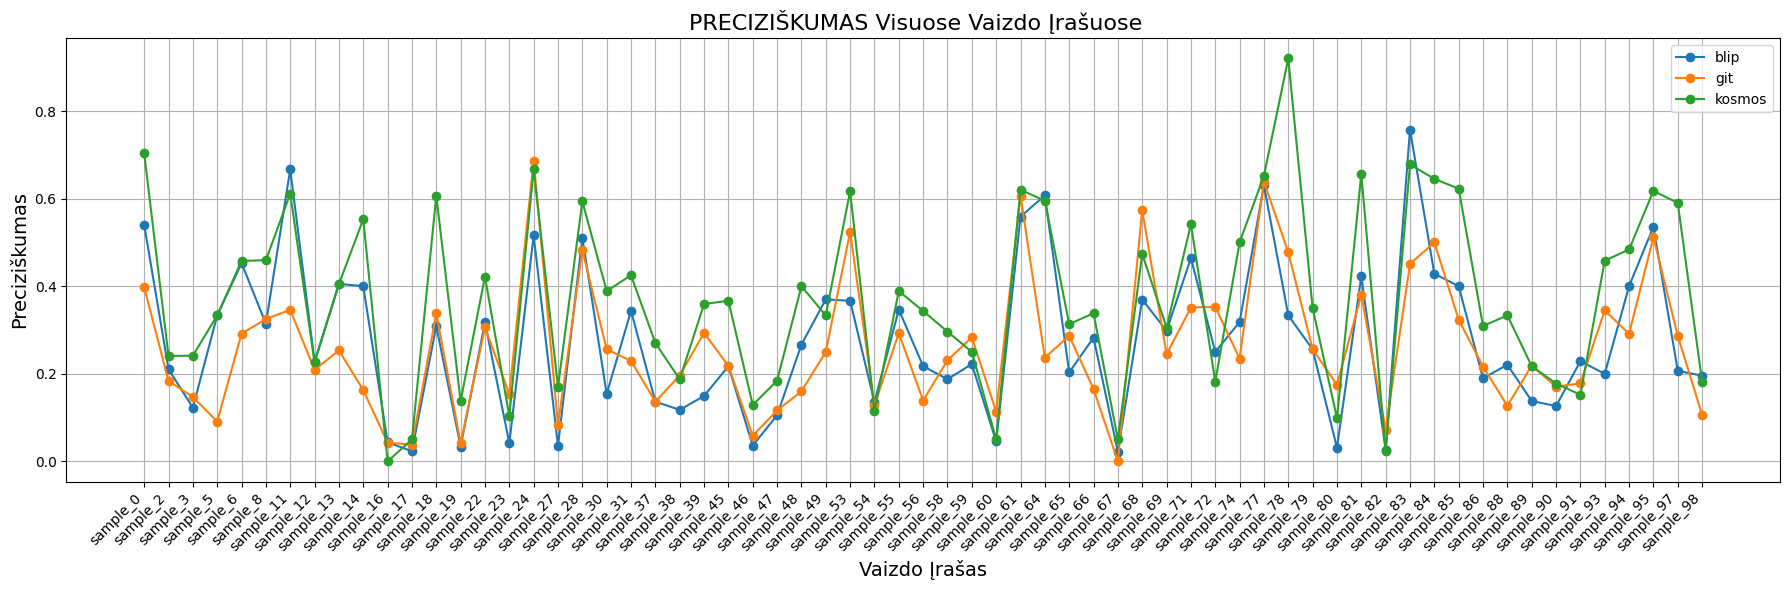

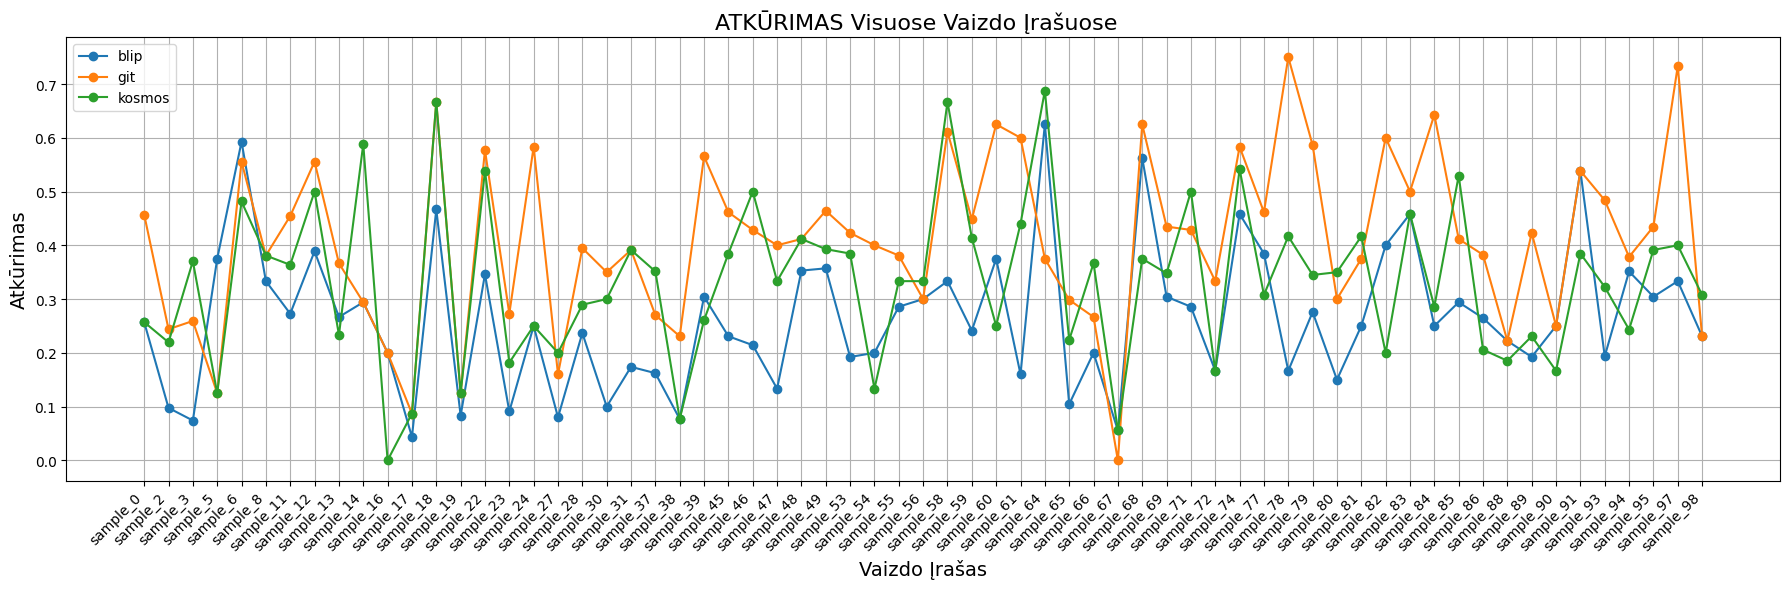

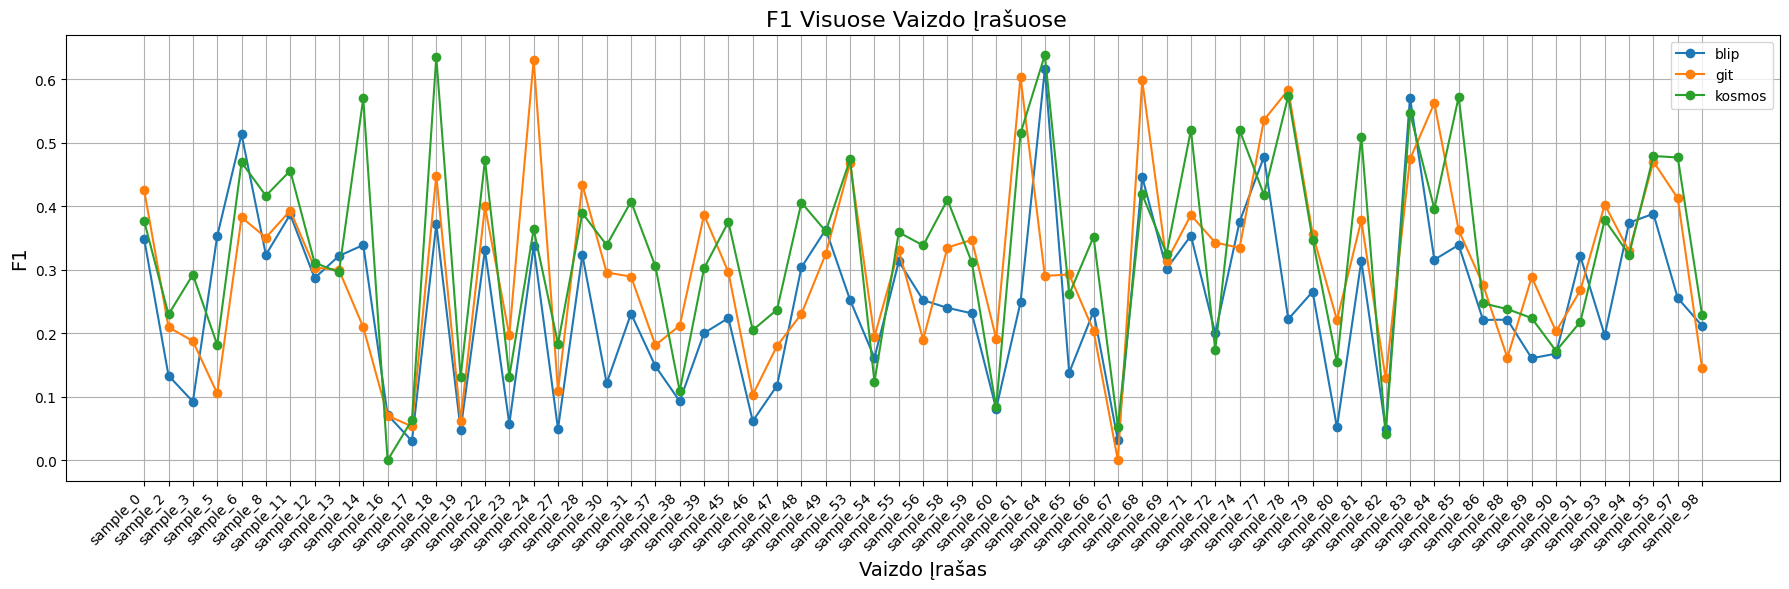

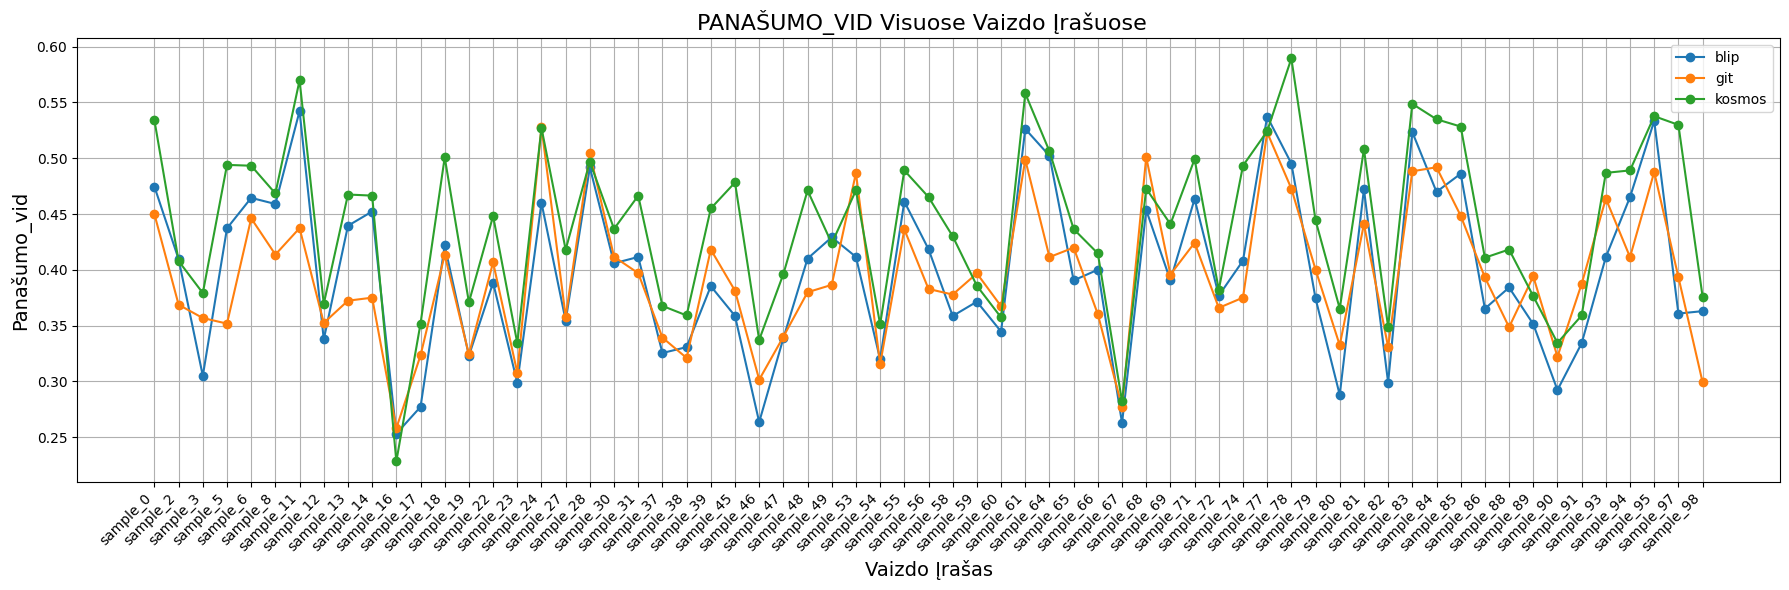

In [ ]:
import json
import matplotlib.pyplot as plt

with open(output_metrics_path, "r") as f:
    results = json.load(f)

metrics = ["precision", "recall", "f1", "avg_sim"]
metric_display_names = {
    "precision": "Preciziškumas",
    "recall": "Atkūrimas",
    "f1": "F1",
    "avg_sim": "Panašumo_vid"
}
video_names = list(results.keys())
model_names = sorted({model for video in results.values() for model in video})

data = {metric: {model: [] for model in model_names} for metric in metrics}

for video in video_names:
    for model in model_names:
        entry = results[video].get(model)
        for metric in metrics:
            val = entry.get(metric) if entry else None
            data[metric][model].append(val)

for metric in metrics:
    plt.figure(figsize=(18, 6))
    for model in model_names:
        plt.plot(video_names, data[metric][model], marker='o', linestyle='-', label=model)
    plt.title(f"{metric_display_names.get(metric, metric).upper()} Visuose Vaizdo Įrašuose  ", fontsize=16)
    plt.xlabel("Vaizdo Įrašas", fontsize=14)
    plt.ylabel(metric_display_names.get(metric, metric), fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


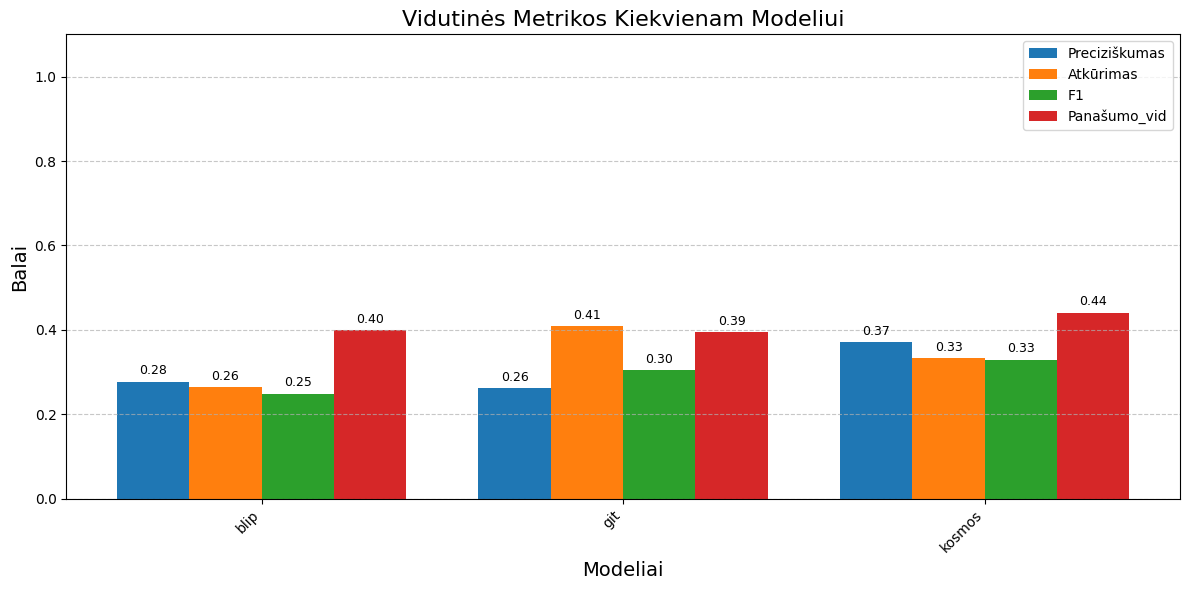

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open(output_metrics_path, "r") as f:
    results = json.load(f)

metrics = ["precision", "recall", "f1", "avg_sim"]
metric_display_names = {
    "precision": "Preciziškumas",
    "recall": "Atkūrimas",
    "f1": "F1",
    "avg_sim": "Panašumo_vid"
}
model_names = sorted({model for video in results.values() for model in video})

aggregated = {model: {metric: [] for metric in metrics} for model in model_names}

for video_data in results.values():
    for model, scores in video_data.items():
        for metric in metrics:
            if metric in scores and scores[metric] is not None:
                aggregated[model][metric].append(scores[metric])

averages = {
    model: {metric: (sum(vals) / len(vals) if vals else 0.0)
            for metric, vals in model_data.items()}
    for model, model_data in aggregated.items()
}

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

offsets = {
    "precision": -1.5 * width,
    "recall": -0.5 * width,
    "f1": 0.5 * width,
    "avg_sim": 1.5 * width,
}

for metric in metrics:
    values = [averages[model][metric] for model in model_names]
    bars = ax.bar(x + offsets[metric], values, width, label=metric_display_names.get(metric, metric))

    for i, val in enumerate(values):
        ax.text(x[i] + offsets[metric], val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=9)

ax.set_title("Vidutinės Metrikos Kiekvienam Modeliui", fontsize=16)
ax.set_xlabel("Modeliai", fontsize=14)
ax.set_ylabel("Balai", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
results = run_all_evaluations_save_results()  # Whisper similarity metrics

Skipping sample_0
Evaluating sample_2...
Average cosine similarity: 0.9539 (0 to 1 scale)
Evaluating sample_3...
Average cosine similarity: 0.9951 (0 to 1 scale)
Evaluating sample_5...
Average cosine similarity: 0.9208 (0 to 1 scale)
Evaluating sample_6...
Average cosine similarity: 0.9350 (0 to 1 scale)
Evaluating sample_8...
Average cosine similarity: 0.9121 (0 to 1 scale)
Evaluating sample_11...
Average cosine similarity: 0.9625 (0 to 1 scale)
Evaluating sample_12...
Average cosine similarity: 0.9397 (0 to 1 scale)
Evaluating sample_13...
Average cosine similarity: 0.9585 (0 to 1 scale)
Evaluating sample_14...
Average cosine similarity: 0.9680 (0 to 1 scale)
Evaluating sample_16...
Average cosine similarity: 0.8601 (0 to 1 scale)
Evaluating sample_17...
Average cosine similarity: 0.9490 (0 to 1 scale)
Evaluating sample_18...
Average cosine similarity: 0.9975 (0 to 1 scale)
Evaluating sample_19...
Average cosine similarity: 0.9295 (0 to 1 scale)
Skipping sample_22
Evaluating sample_2

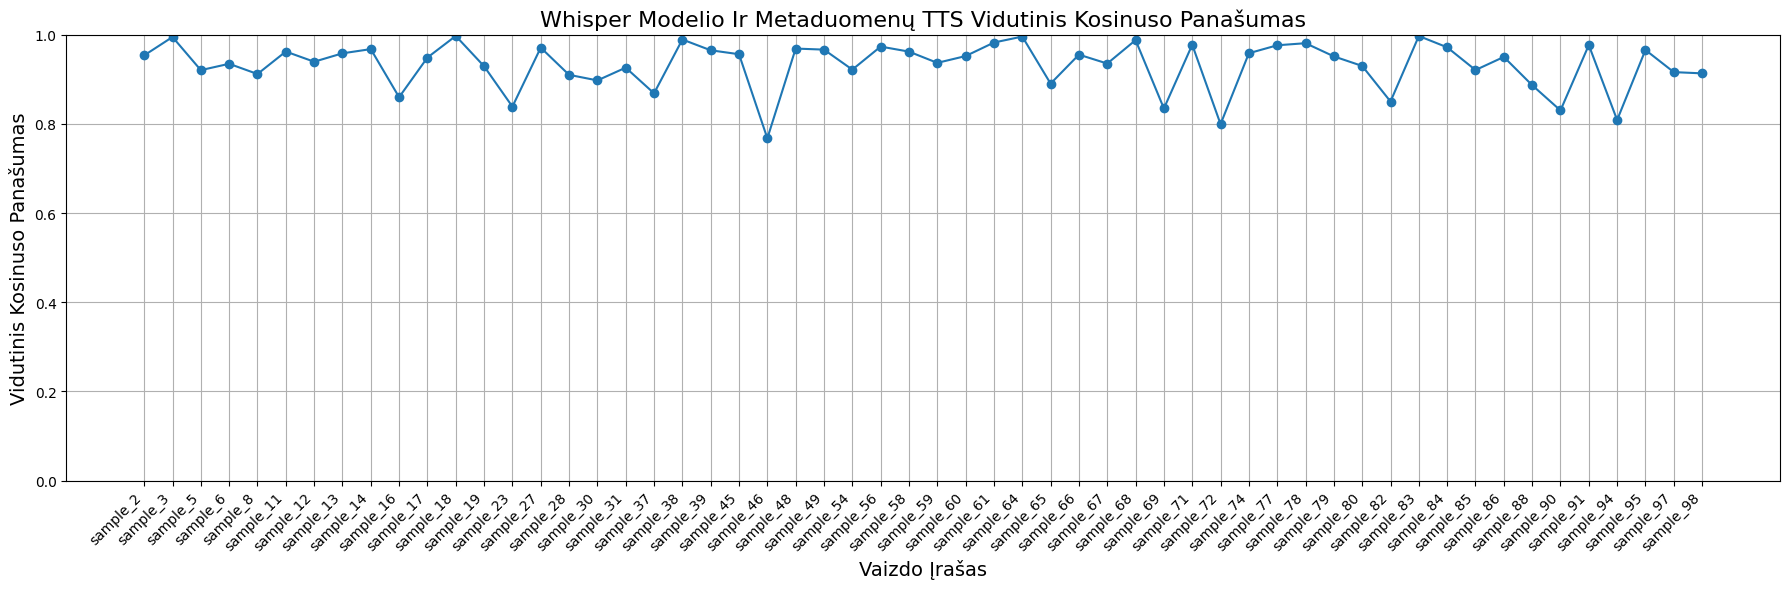

In [ ]:
import json
import matplotlib.pyplot as plt
import re

with open(output_metrics_path_whisper, "r", encoding="utf-8") as f:
    results = json.load(f)

sorted_items = sorted(results.items(), key=lambda x: int(re.search(r'\d+', x[0]).group()))
video_names = [k for k, _ in sorted_items]
similarities = [v for _, v in sorted_items]

plt.figure(figsize=(18, 6))
plt.plot(video_names, similarities, marker='o', linestyle='-')
plt.title("Whisper Modelio Ir Metaduomenų TTS Vidutinis Kosinuso Panašumas", fontsize=16)
plt.xlabel("Vaizdo Įrašas", fontsize=14)
plt.ylabel("Vidutinis Kosinuso Panašumas", fontsize=14)
plt.ylim(0, 1)
plt.grid(True)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
run_ingredients_evaluation(metadata_dir, models, output_metrics_path_ingredients)  # Ingredient metrics

Srautinio perdavimo išvestis sutrumpinta iki kelių paskutinių eilučių (5000).
  - white chocolate chips

Percent found in metadata (exact): 45.45%

Found in metadata (with synonyms):
  - all purpose flour
  - brown sugar
  - butter
  - chocolate chips
  - egg
  - old fashioned rolled oats
  - salt
  - white chocolate chips

Missing in metadata (with synonyms):
  - cranberries
  - regular gluten free
  - walnuts

Percent found in metadata (with synonyms): 72.73%

Ingredients found in JSON by any model (Exact) (7):
  - brown sugar
  - butter
  - chocolate chips
  - egg
  - oats
  - rolled oats
  - salt

Percentage of JSON ingredients found by each model (Exact):
  - blip: 2/7 (28.57%)
  - kosmos: 3/7 (42.86%)
  - git: 1/7 (14.29%)
  - whisper: 5/7 (71.43%)

Ingredients found in JSON by any model (Synonyms) (11):
  - all purpose flour
  - brown sugar
  - butter
  - chocolate chips
  - coconut oil
  - egg
  - oats
  - old fashioned rolled oats
  - rolled oats
  - salt
  - white chocolate c


Table for percent_found_in_captions_exact:
                 blip      kosmos         git     whisper
sample_0   14.285714   73.333333   72.727273   81.250000
sample_2   50.000000   83.333333  100.000000   77.777778
sample_3   20.000000   66.666667   50.000000   77.777778
sample_5    0.000000   85.714286    0.000000    0.000000
sample_6   35.294118   75.675676   50.000000  100.000000
...              ...         ...         ...         ...
sample_93  88.888889   71.428571   42.857143   87.500000
sample_94   0.000000  100.000000  100.000000   88.888889
sample_95  20.000000   37.500000   62.500000   58.333333
sample_97   0.000000   46.153846   55.555556  100.000000
sample_98  71.428571  100.000000   45.454545  100.000000

[65 rows x 4 columns]

Table for percent_found_in_captions_synonyms:
                  blip      kosmos         git     whisper
sample_0    42.857143   86.666667   81.818182   87.500000
sample_2   100.000000  100.000000  100.000000  100.000000
sample_3    20.000000   66

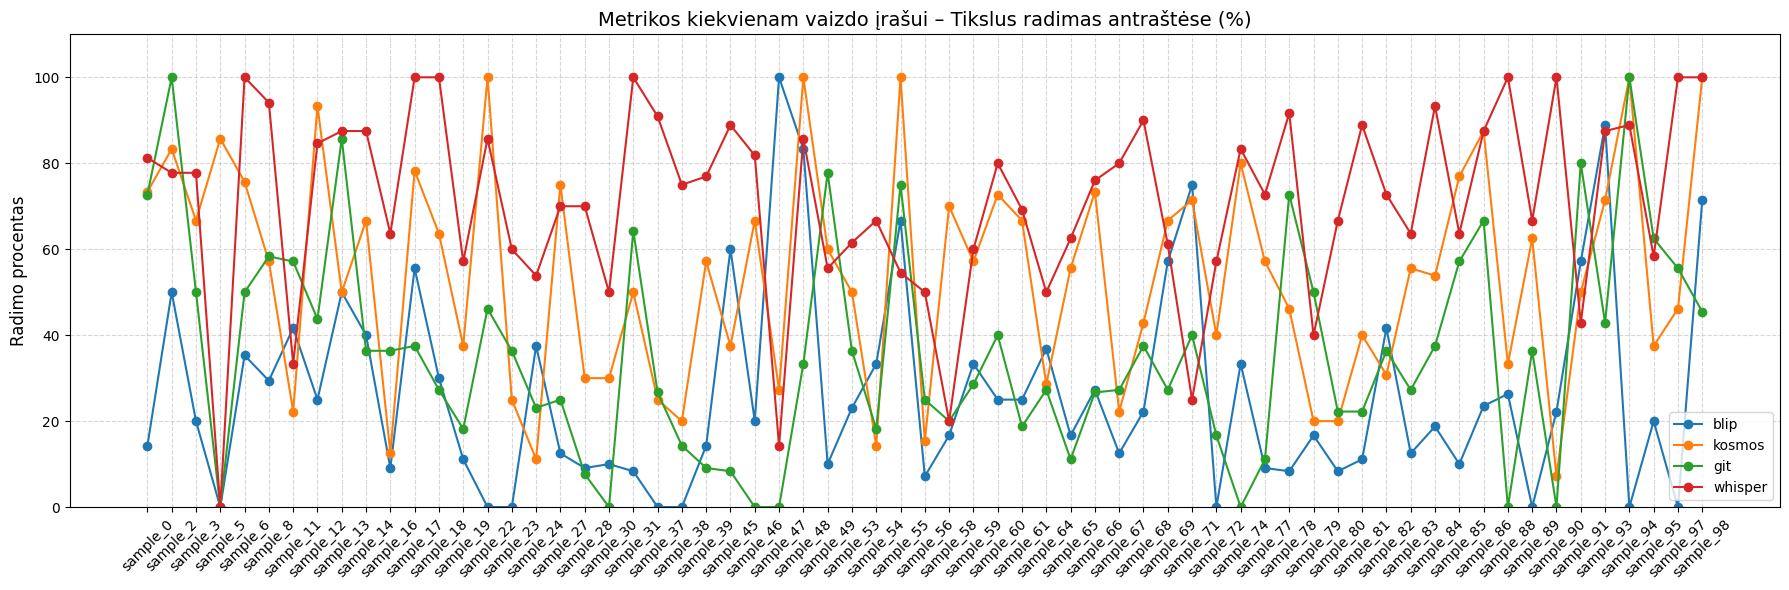

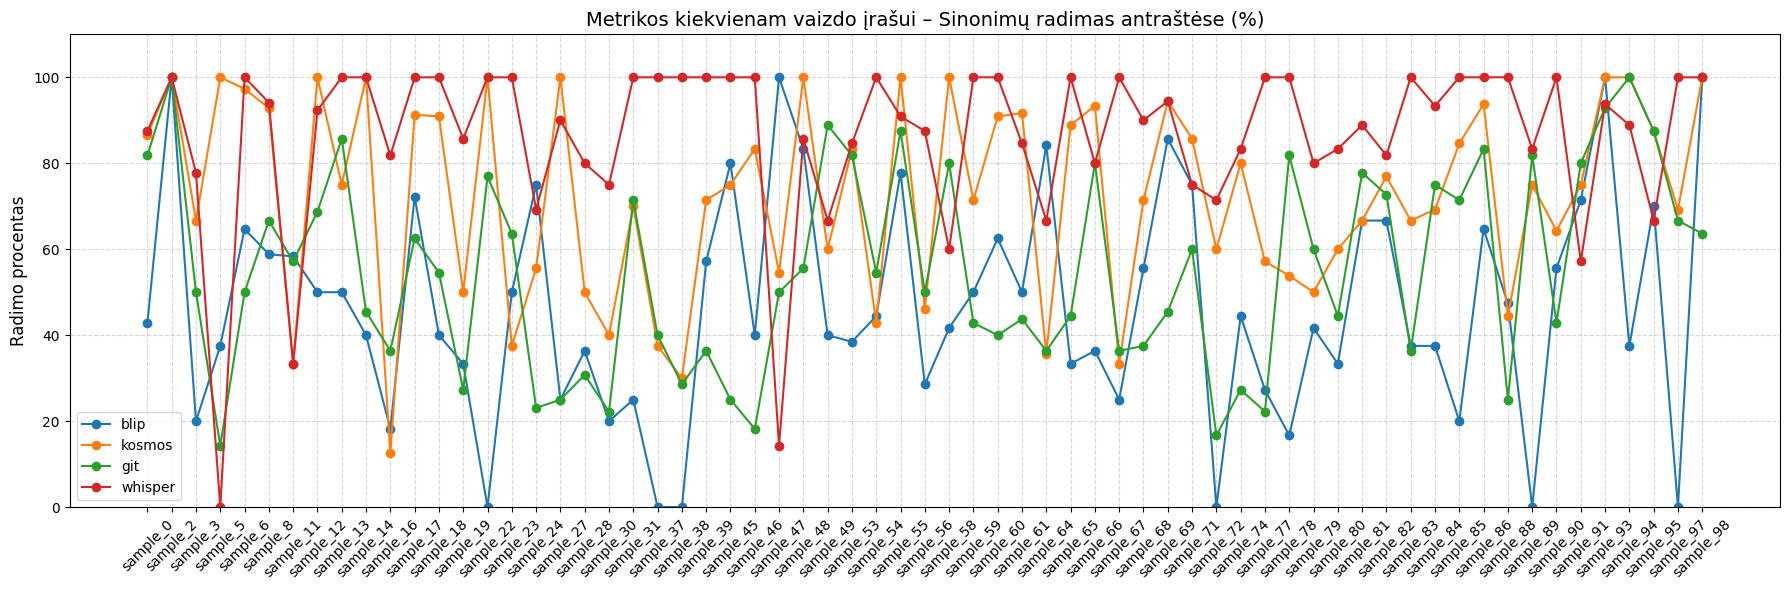

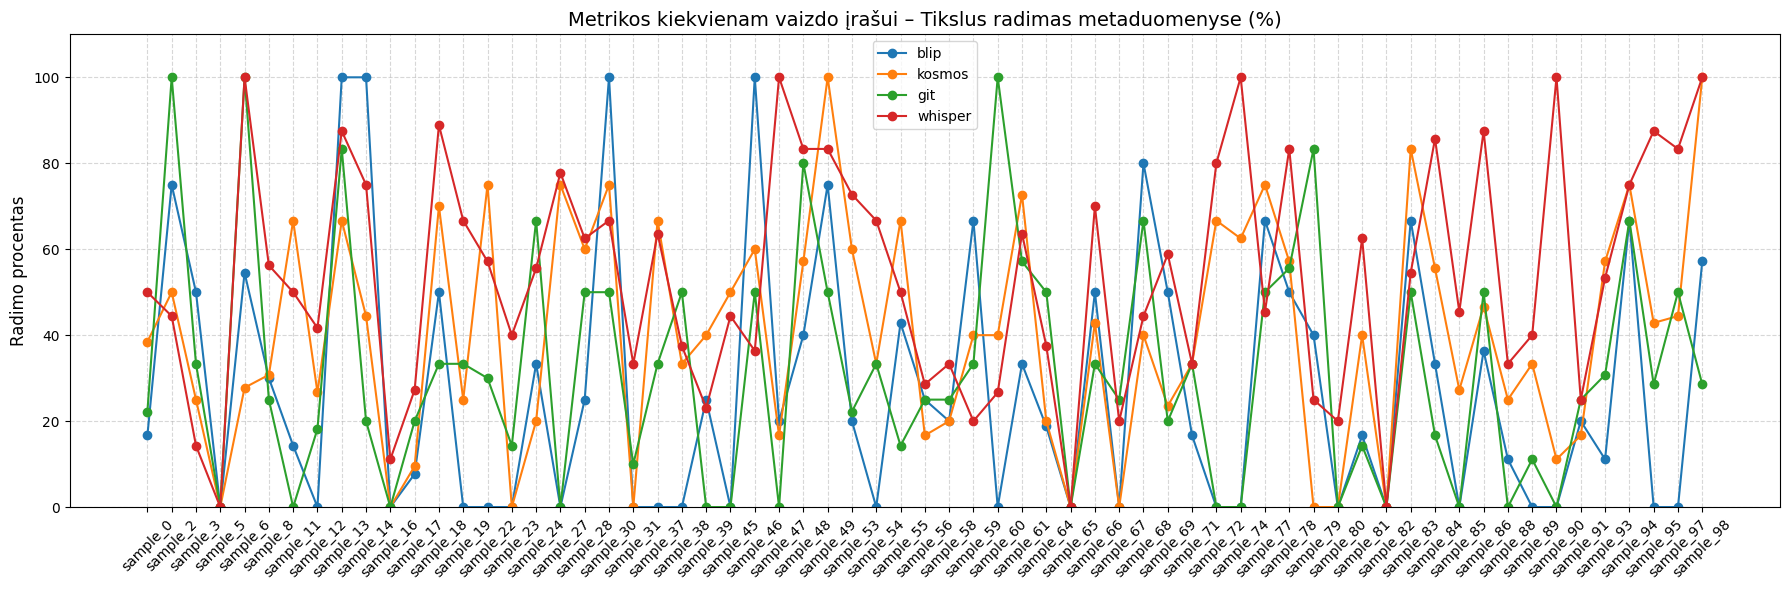

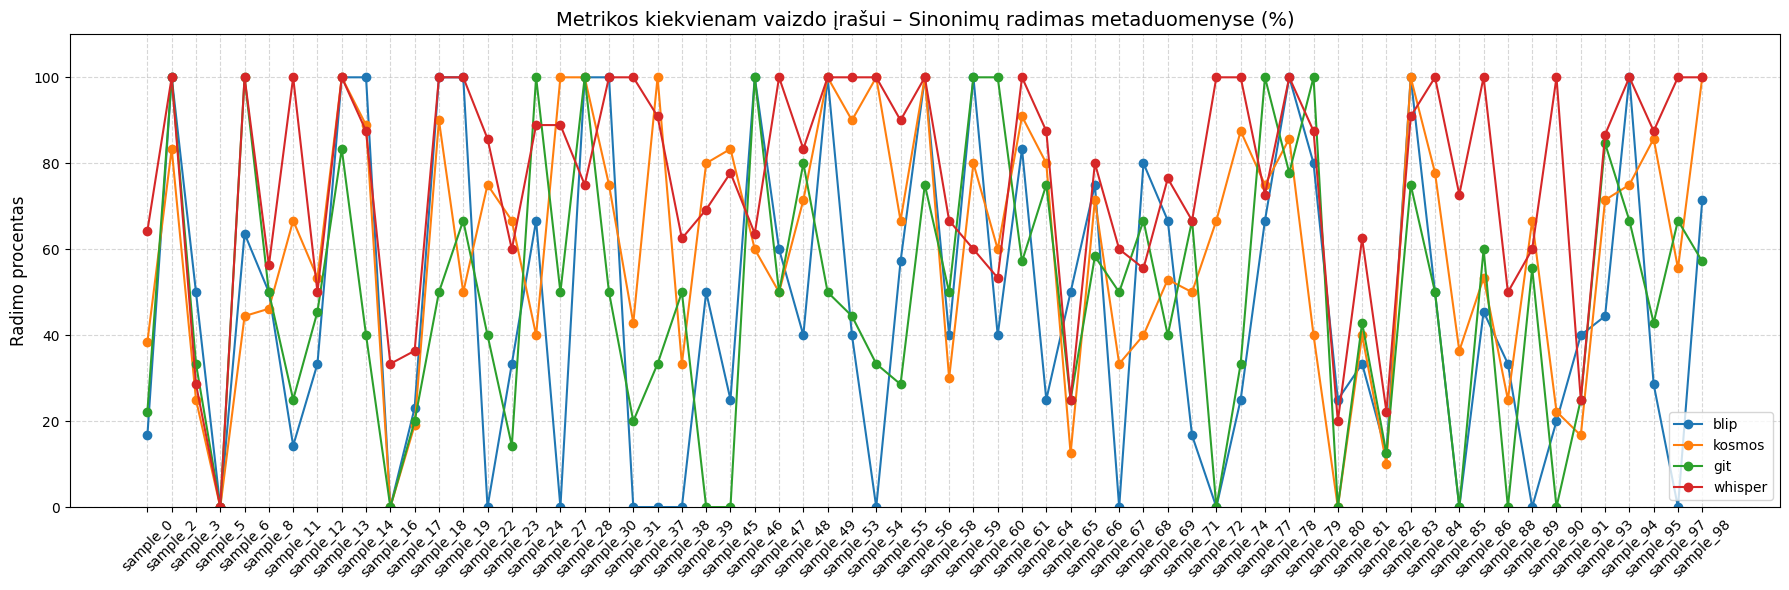

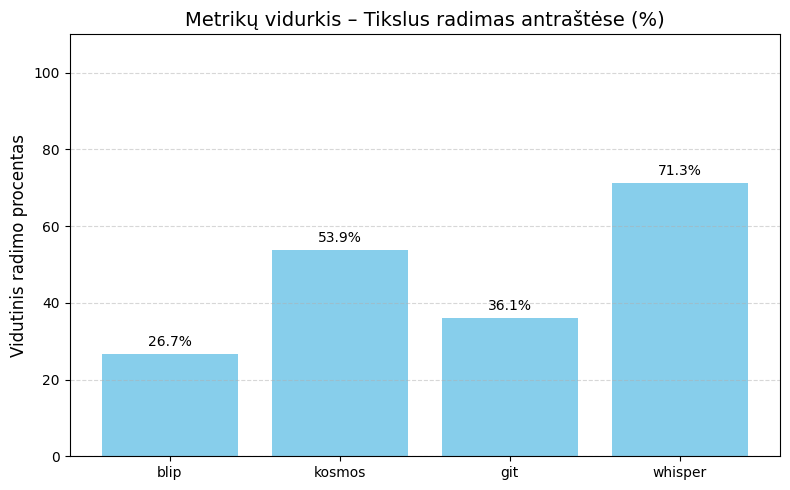

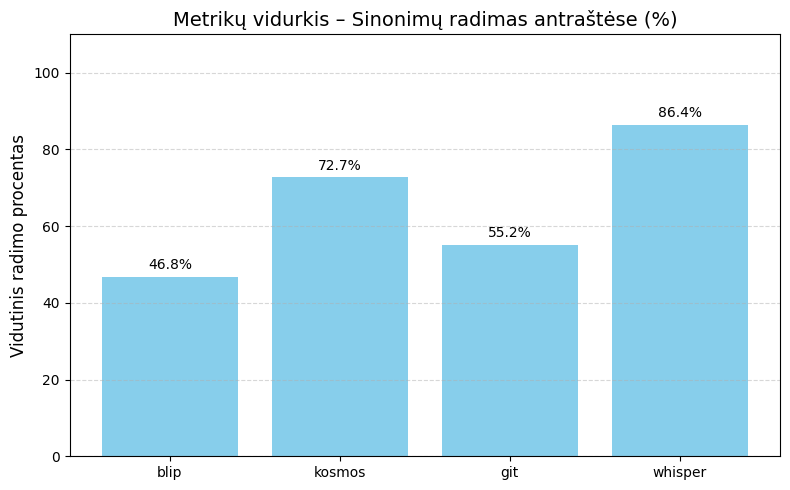

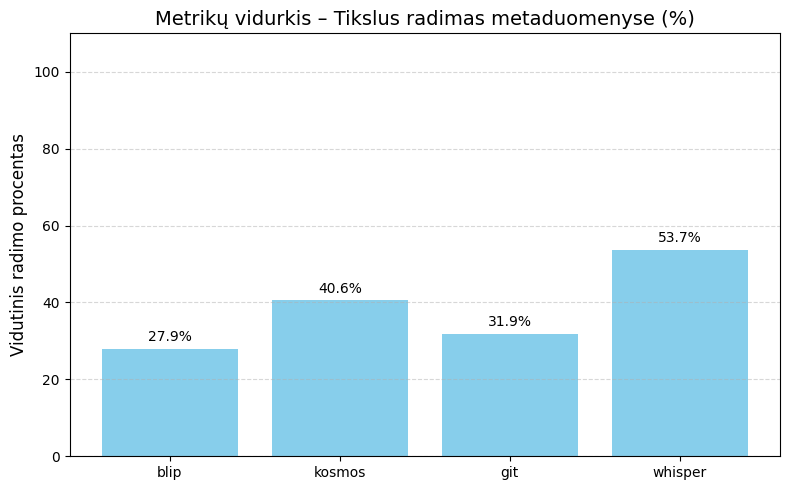

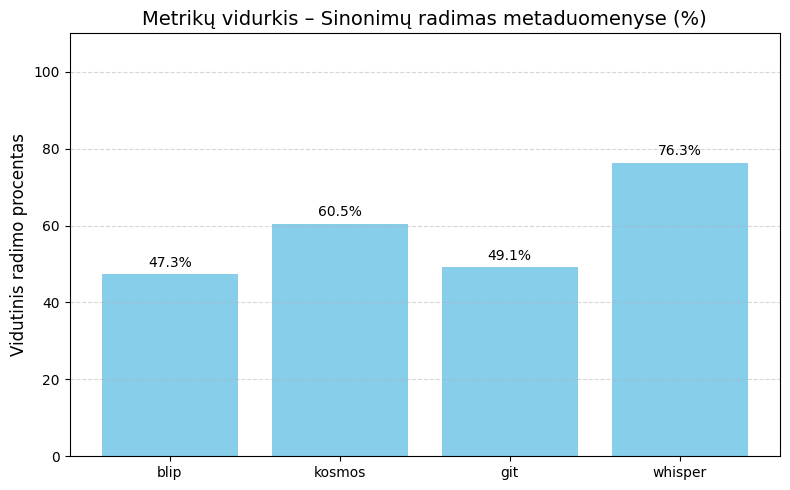

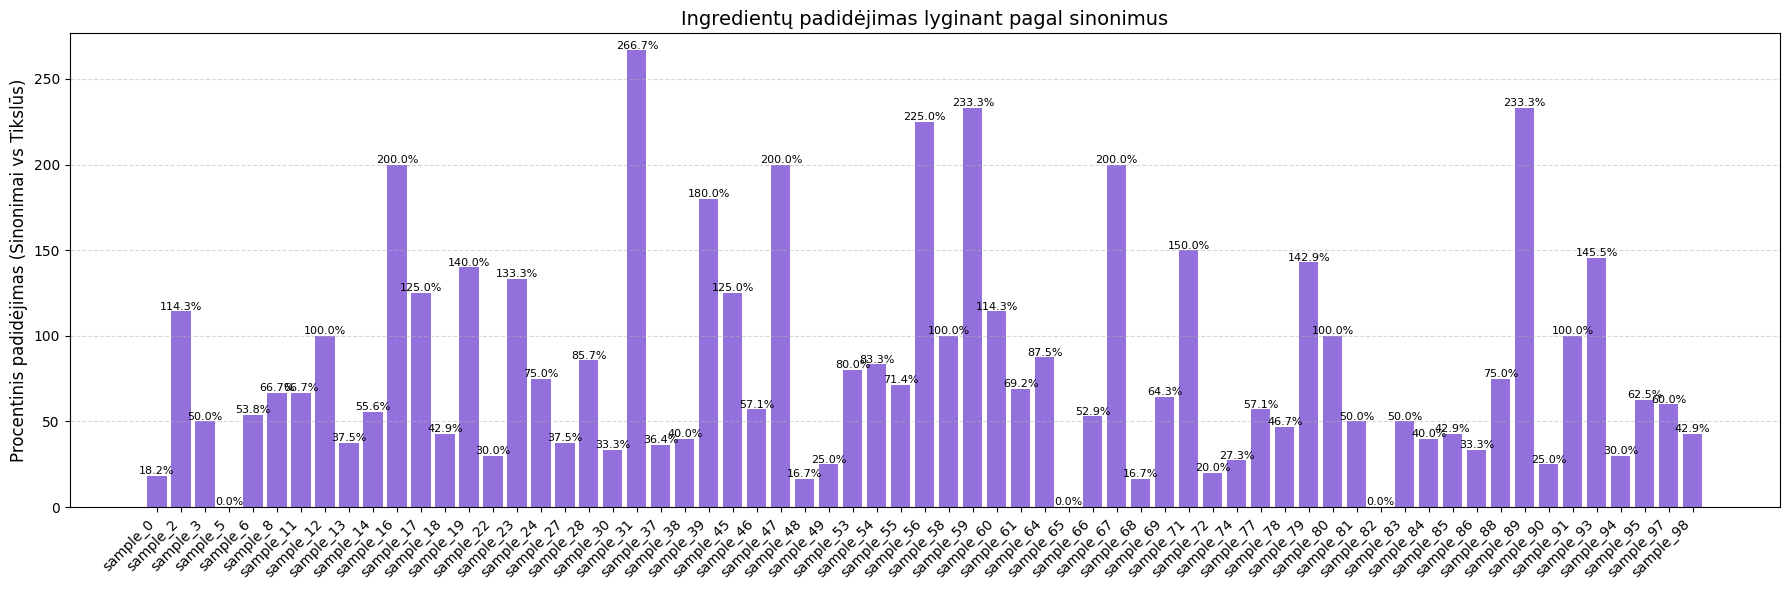


Average Percentages (Exact vs Synonyms):
             Exact   Synonyms
blip     20.906801  21.083455
kosmos   43.348624  38.140162
git      24.770642  22.776280
whisper  68.348624  56.738544


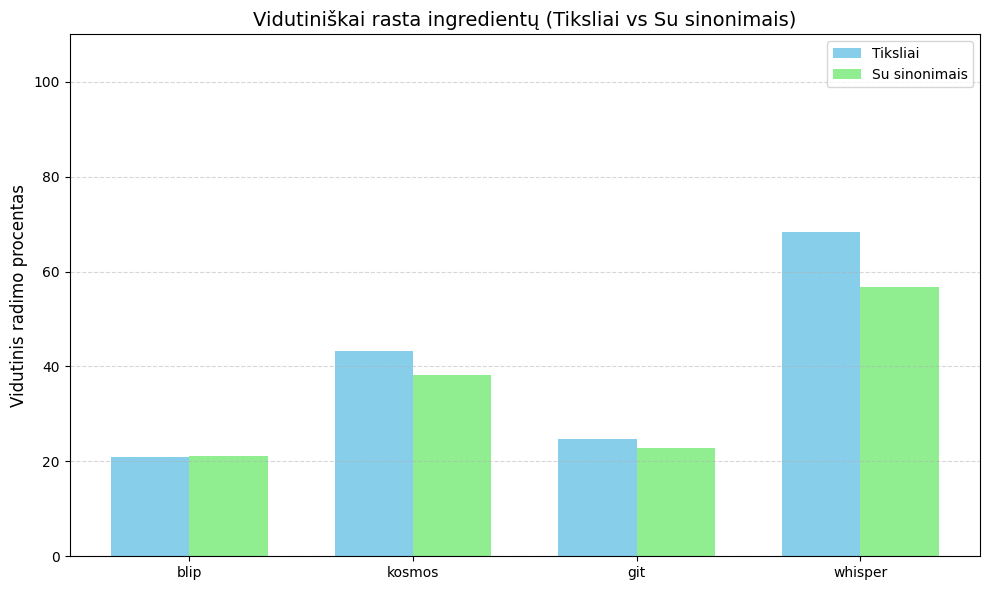

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

with open(output_metrics_path_ingredients) as f:
    data = json.load(f)

models = ['blip', 'kosmos', 'git', 'whisper']

sample_keys = [k for k in data.keys() if k.startswith("sample_")]

metrics_list = [
    "percent_found_in_captions_exact",
    "percent_found_in_captions_synonyms",
    "percent_found_in_metadata_exact",
    "percent_found_in_metadata_synonyms"
]

metric_display_names = {
    "percent_found_in_captions_exact": "Tikslus radimas antraštėse (%)",
    "percent_found_in_captions_synonyms": "Sinonimų radimas antraštėse (%)",
    "percent_found_in_metadata_exact": "Tikslus radimas metaduomenyse (%)",
    "percent_found_in_metadata_synonyms": "Sinonimų radimas metaduomenyse (%)"
}

translated_title = {
    "exact_vs_synonyms": "Vidutiniškai rasta ingredientų (Tiksliai vs Su sinonimais)",
    "increase_per_sample": "Ingredientų padidėjimas lyginant pagal sinonimus",
    "average_metric_title": "Metrikų vidurkis",
    "metric_per_sample": "Metrikos kiekvienam vaizdo įrašui"
}

metric_tables = {}

for metric in metrics_list:
    rows = []
    for sample_key in sample_keys:
        sample = data[sample_key]
        row = {}
        metrics = sample.get("metrics", {})
        for model in models:
            val = None
            if model in metrics:
                val = metrics[model].get(metric)
                if val is None:
                    val = 0.0
            else:
                val = 0.0
            row[model] = val
        rows.append(row)
    df = pd.DataFrame(rows, index=sample_keys)
    metric_tables[metric] = df

for metric, df in metric_tables.items():
    print(f"\nTable for {metric}:\n", df)

for metric, df in metric_tables.items():
    plt.figure(figsize=(18, 6))
    for model in models:
        plt.plot(df.index, df[model], marker='o', label=model)
    plt.title(translated_title["metric_per_sample"] + f" – {metric_display_names.get(metric, metric)}", fontsize=14)
    plt.ylabel("Radimo procentas", fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



avg_metrics_per_model = {metric: metric_tables[metric].mean(axis=0) for metric in metrics_list}

for metric, series in avg_metrics_per_model.items():
    plt.figure(figsize=(8, 5))
    bars = plt.bar(series.index, series.values, color='skyblue')
    plt.ylim(0, 110)
    plt.ylabel("Vidutinis radimo procentas", fontsize=12)
    plt.title(f"{translated_title['average_metric_title']} – {metric_display_names.get(metric, metric)}", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 2, f"{height:.1f}%", ha='center')
    plt.tight_layout()
    plt.show()



sample_names = []
percent_increases = []

for sample_key in sample_keys:
    gain = data[sample_key].get("synonyms_vs_exact_gain", {})
    percent = gain.get("percent_increase", 0.0)
    sample_names.append(sample_key)
    percent_increases.append(percent)

plt.figure(figsize=(18, 6))
bars = plt.bar(sample_names, percent_increases, color='mediumpurple')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Procentinis padidėjimas (Sinonimai vs Tikslūs)', fontsize=12)
plt.title(translated_title["increase_per_sample"], fontsize=14)
plt.ylim(0, max(percent_increases) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%", ha='center', fontsize=8)

plt.tight_layout()
plt.show()



avg_exact = data['average_percentages_Exact']
avg_synonyms = data['average_percentages_Synonyms']

df_avg = pd.DataFrame({
    'Exact': [avg_exact[m] for m in models],
    'Synonyms': [avg_synonyms[m] for m in models]
}, index=models)

print("\nAverage Percentages (Exact vs Synonyms):")
print(df_avg)

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df_avg['Exact'], width, label='Tiksliai', color='skyblue')
plt.bar(x + width/2, df_avg['Synonyms'], width, label='Su sinonimais', color='lightgreen')
plt.xticks(x, models)
plt.ylabel('Vidutinis radimo procentas', fontsize=12)
plt.title(translated_title["exact_vs_synonyms"], fontsize=14)
plt.legend()
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


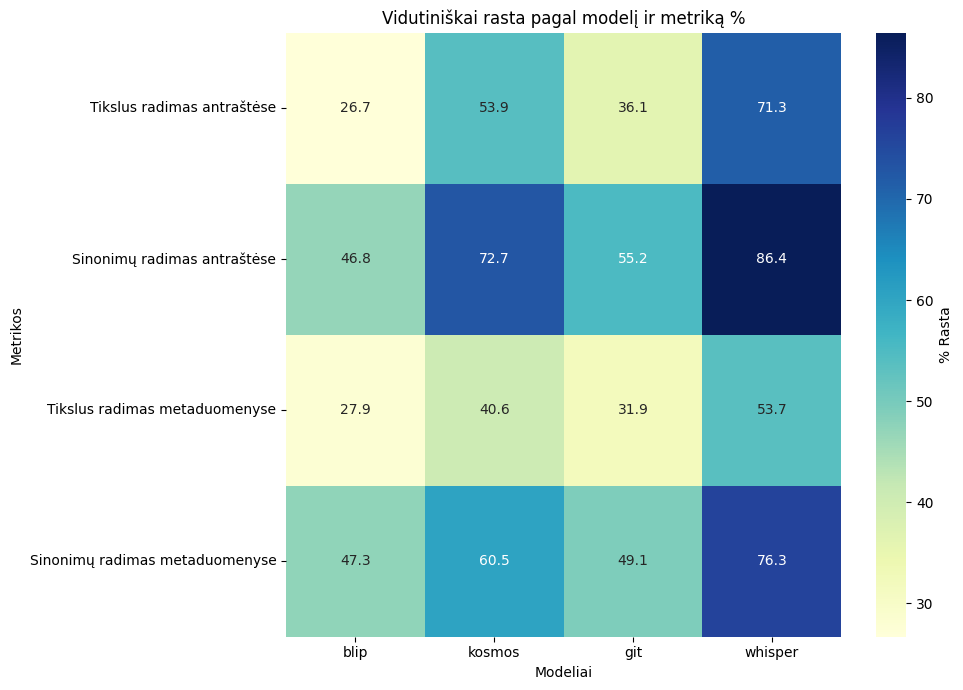

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

models = ['blip', 'kosmos', 'git', 'whisper']
metric_names = {
    "percent_found_in_captions_exact": "Tikslus radimas antraštėse",
    "percent_found_in_captions_synonyms": "Sinonimų radimas antraštėse",
    "percent_found_in_metadata_exact": "Tikslus radimas metaduomenyse",
    "percent_found_in_metadata_synonyms": "Sinonimų radimas metaduomenyse"
}

avg_metrics_per_model = {
    metric_names[metric]: metric_tables[metric].mean(axis=0) for metric in metric_tables
}

df_combined = pd.DataFrame(avg_metrics_per_model).T[models]

plt.figure(figsize=(10, 7))
sns.heatmap(df_combined, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "% Rasta"})
plt.title("Vidutiniškai rasta pagal modelį ir metriką %")
plt.ylabel("Metrikos")
plt.xlabel("Modeliai")
plt.tight_layout()
plt.show()


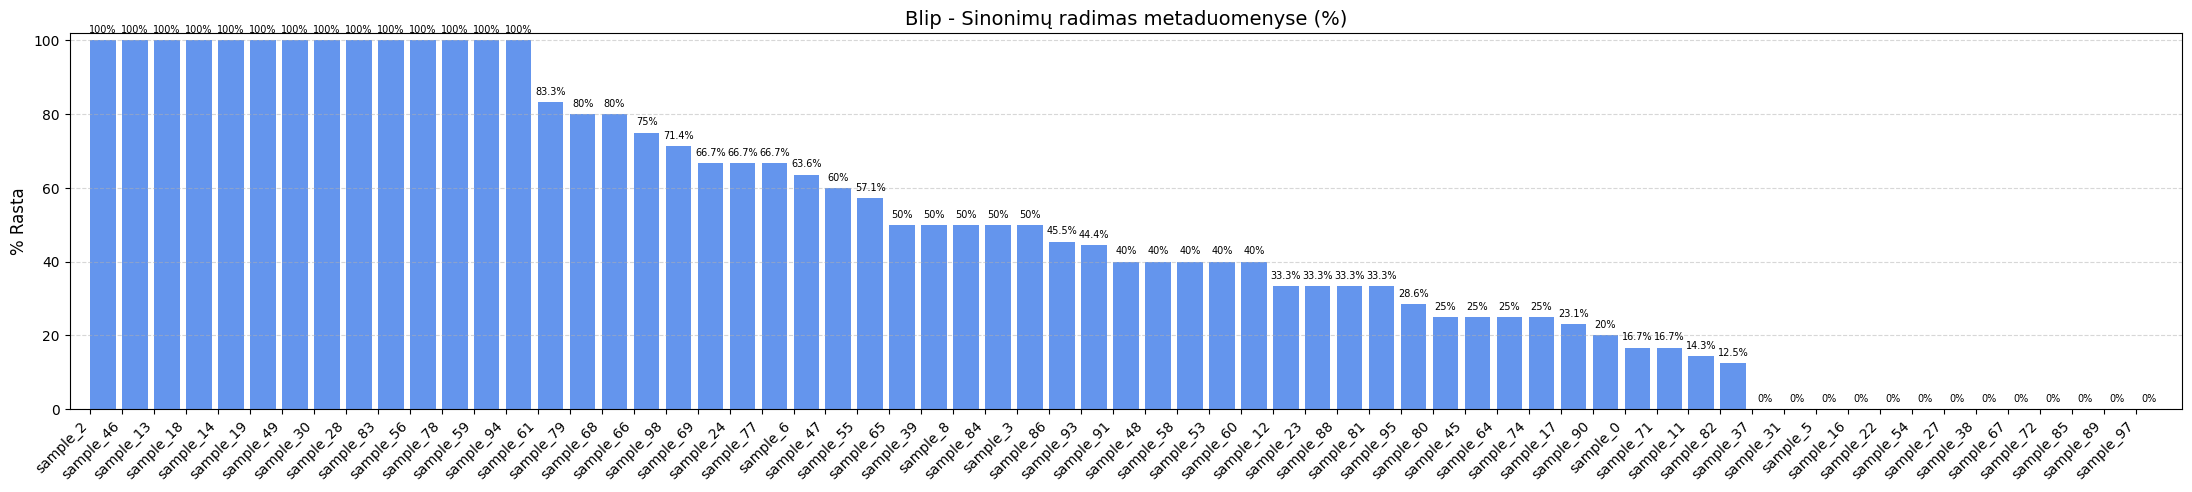

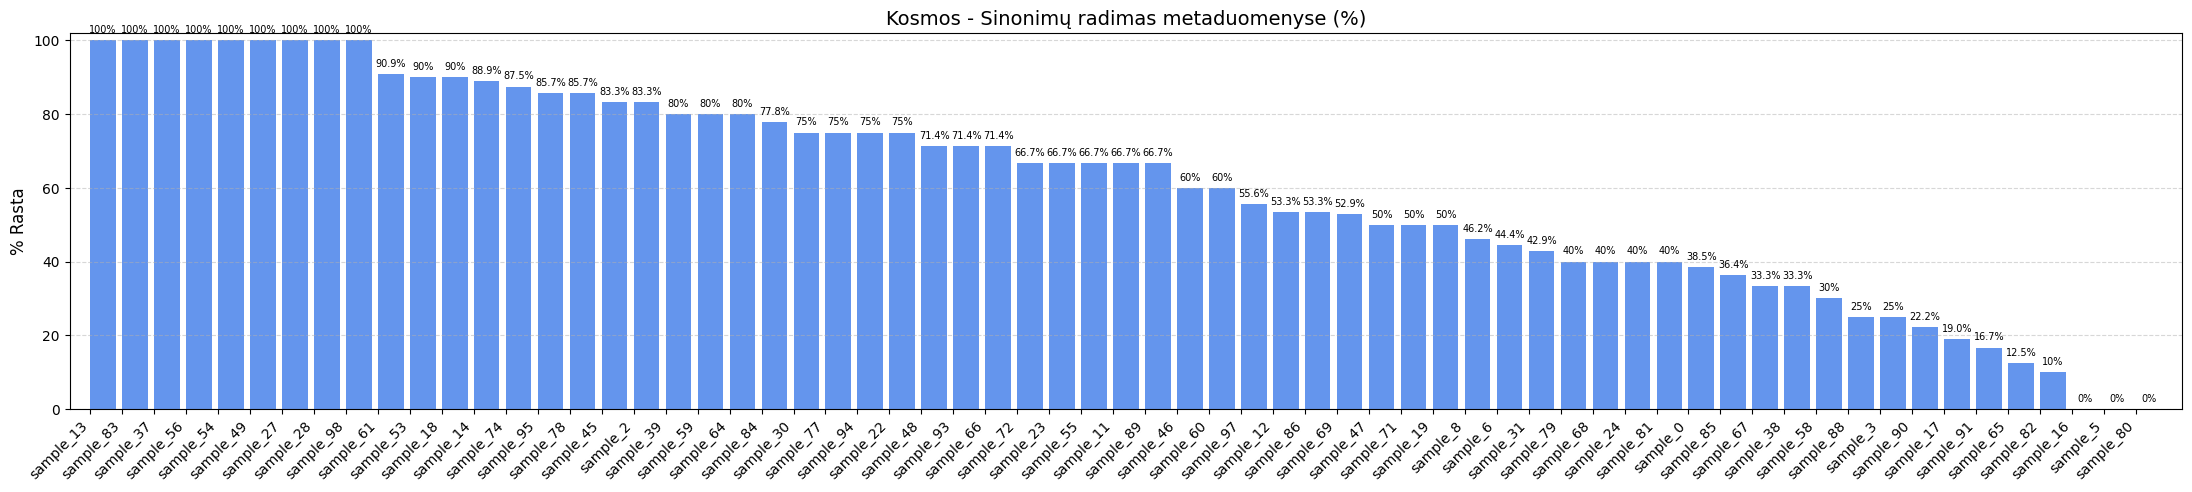

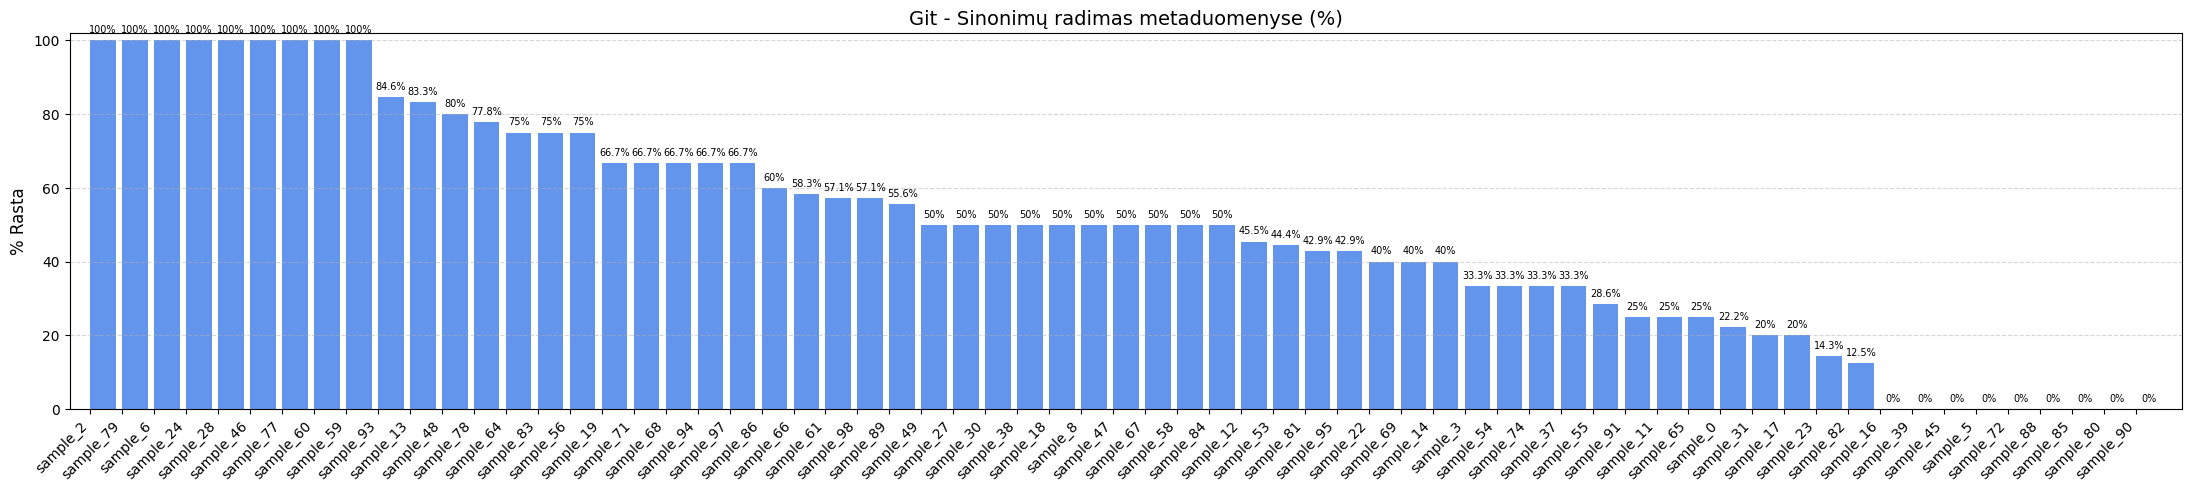

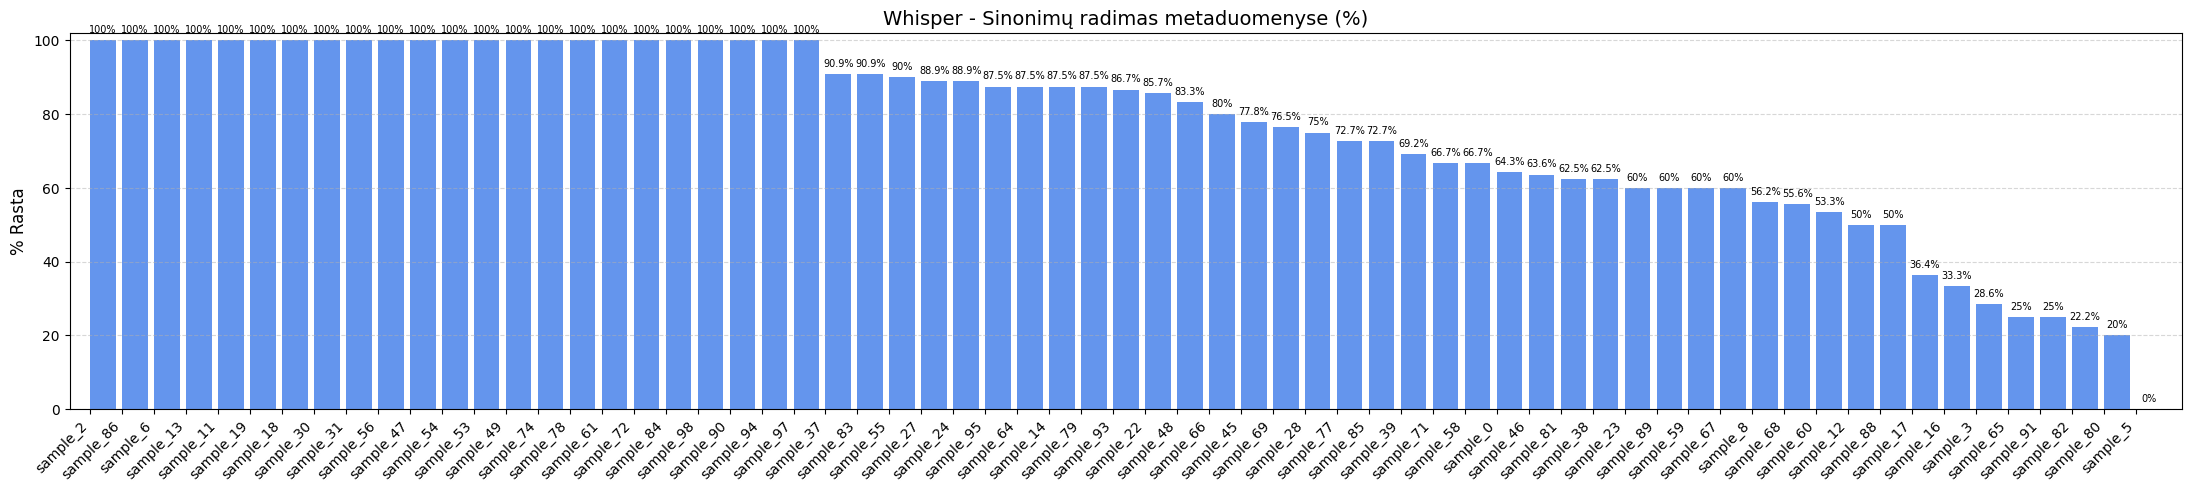

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

metric = "percent_found_in_metadata_synonyms"
metric_display_name = "Sinonimų radimas metaduomenyse (%)"
df = metric_tables[metric]

for model in models:
    model_values = df[model]
    sorted_values = model_values.sort_values(ascending=False)
    sample_names = sorted_values.index
    values = sorted_values.values

    plt.figure(figsize=(22, 5))
    bars = plt.bar(sample_names, values, color='cornflowerblue', align='edge', width=0.8)

    plt.title(f"{model.title()} - {metric_display_name }", fontsize=14)
    plt.ylabel("% Rasta", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, max(values) + 2)
    plt.margins(x=0.01)
    plt.grid(axis='y', linestyle='--', alpha=0.5)


    for bar in bars:
        height = bar.get_height()
        label = f"{int(height)}%" if height.is_integer() else f"{height:.1f}%"
        plt.text(bar.get_x() + bar.get_width()/2, height + 2, label, ha='center', fontsize=7)

    plt.tight_layout(pad=1.0)
    plt.show()


**API UI**

In [ ]:
!pip install flask flask-ngrok --quiet
!apt-get install -y ffmpeg > /dev/null 2>&1

import os
from flask import Flask, request, render_template_string
from flask_ngrok import run_with_ngrok
from google.colab.output import eval_js


output_dir_captions = "/content/captions"
os.makedirs(output_dir_captions, exist_ok=True)

app = Flask(__name__)

UPLOAD_FOLDER = "/content/uploads"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

@app.route('/')
def home():
    html = """
    <html>
    <head>
      <title>NeuralReel - Cooking Video to Recipe</title>
      <style>
        body {
          font-family: Arial, sans-serif;
          margin: 40px;
          background: #fdfdfd;
          color: #333;
        }
        .container {
          max-width: 600px;
          margin: auto;
          padding: 30px;
          border: 1px solid #ddd;
          border-radius: 10px;
          background: #fff;
          box-shadow: 0 0 10px rgba(0,0,0,0.1);
        }
        h2 { color: #2c3e50; }
        select, input[type="file"], input[type="submit"] {
          margin-top: 10px;
          width: 100%;
          padding: 10px;
          font-size: 1em;
          border-radius: 5px;
          border: 1px solid #ccc;
        }
        input[type="submit"] {
          background-color: #3498db;
          color: white;
          border: none;
          cursor: pointer;
        }
        input[type="submit"]:hover {
          background-color: #2980b9;
        }
      </style>
    </head>
    <body>
      <div class="container">
        <h2>Upload a Cooking Video for NeuralReel Processing</h2>
        <form method="POST" action="/upload_video" enctype="multipart/form-data">
          <input type="file" name="video_file" accept="video/mp4" required><br>
          <label>Select model to describe frames:</label><br>
          <select name="model_name" required>
            <option value="blip">BLIP</option>
            <option value="git">GIT</option>
            <option value="kosmos">KOSMOS</option>
            <option value="whisper">WHISPER (audio transcription)</option>
          </select><br><br>
          <input type="submit" value="Upload & Process">
        </form>
      </div>
    </body>
    </html>
    """
    return render_template_string(html)


@app.route('/upload_video', methods=['POST'])
def upload_video():
    if 'video_file' not in request.files:
        return "No video file part", 400

    file = request.files['video_file']
    model_name = request.form.get('model_name')

    if file.filename == '':
        return "No selected file", 400
    if model_name not in ['blip', 'git', 'kosmos', 'whisper']:
        return "Invalid model name", 400

    video_path = os.path.join(UPLOAD_FOLDER, file.filename)
    file.save(video_path)

    video_name = os.path.splitext(file.filename)[0]
    frame_dir = os.path.join("/content/frames", video_name)
    os.makedirs(frame_dir, exist_ok=True)

    try:
        extract_frames_by_time(video_path, frame_dir, interval_sec=1)
    except Exception as e:
        return f"<h3>Frame extraction failed:</h3><pre>{str(e)}</pre>", 500

    try:
        if model_name == 'blip':
            recipe = process_video_frames_UI(frame_dir, describe_blip, output_suffix="_blip", video_name=video_name)
        elif model_name == 'git':
            recipe = process_video_frames_UI(frame_dir, describe_git, output_suffix="_git", video_name=video_name)
        elif model_name == 'kosmos':
            recipe = process_video_frames_UI(frame_dir, describe_kosmos, output_suffix="_kosmos", video_name=video_name)
        elif model_name == 'whisper':
            recipe = process_video_whisper_UI(video_path, output_dir, output_dir_captions, output_suffix="_whisper")
        else:
            return "Unsupported model", 400
    except Exception as e:
        return f"<h3>Processing failed:</h3><pre>{str(e)}</pre>", 500

    return f"""
    <h2>Recipe Generated Using {model_name.upper()} Model</h2>
    <pre style="background-color:#f4f4f4;padding:1em;border-radius:8px;">{recipe}</pre>
    <a href="/">Go back</a>
    """

print(eval_js("google.colab.kernel.proxyPort(5000)"))
app.run()


https://5000-gpu-t4-s-19s6jykplyo2t-a.europe-west4-1.prod.colab.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [24/May/2025 12:39:23] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/May/2025 12:39:24] "GET /favicon.ico HTTP/1.1" 404 -


Added: a man in a black hoodie and a little girl in a green shirt
Added: a man in a black hoodie is holding a plate with a sandwich
Added: a man and a little girl are eating apples
Added: a man and a little girl are eating food
Added: a man and a little girl are in the kitchen
Added: a wooden table topped with spices and seasonings
Added: the ingredients for the homemade burger seasoning ingredients
Added: the ingredients for the homemade spice
Added: a person is holding a bowl of food


INFO:werkzeug:127.0.0.1 - - [24/May/2025 12:40:31] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/May/2025 12:40:32] "POST /upload_video HTTP/1.1" 200 -


Added: a man and a young girl standing in a kitchen. The man is wearing a hat, and the girl is
Added: a man and a little girl standing in a kitchen, both holding apples. The man is wearing a baseball cap
Added: a wooden cutting board with various spices spread out on it. The spices include salt, pepper, garlic powder,
Added: a white bowl filled with a mixture of spices and a dollop of ketchup. The bowl is placed on a wooden
Added: a person's hands mixing a bowl of cinnamon sugar. The person is using their hands to mix the ingredients
Added: a person holding a small bowl filled with a red substance. The bowl is placed on a table, and the


INFO:werkzeug:127.0.0.1 - - [24/May/2025 12:41:32] "POST /upload_video HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/May/2025 12:43:40] "GET / HTTP/1.1" 200 -


Added: a pink background with a solid pink rectangle in the center. The rectangle is slightly smaller than the pink background,
Added: a pink background with a neon heart shape in the center. There are several small white hearts scattered around the heart
Added: a young woman with long brown hair, who is smiling and looking off to the side. She is wearing a
Added: a cartoon-style drawing of a girl with long hair and a bow, surrounded by hearts. The background is
Added: a cartoon-style drawing of a woman with long brown hair. She is holding a paintbrush and appears to be
Added: a cartoon-like girl with long hair and a bow in her hair. She is smiling and appears to be
Added: a young woman with long hair and a white glove. She is smiling and appears to be holding a paintbrush.
Added: a pink background with a YouTube icon and a subscribe button. The subscribe button is positioned at the top left corner
Added: a black background with a white logo on the left side. The logo is a small, white

INFO:werkzeug:127.0.0.1 - - [24/May/2025 12:45:58] "POST /upload_video HTTP/1.1" 200 -


In [ ]:
def process_video_frames_UI(frame_dir, describe_fn, output_suffix="", video_name=""):
    frame_files = sorted([os.path.join(frame_dir, f) for f in os.listdir(frame_dir) if f.endswith('.jpg')])
    captions, seen = [], set()

    for frame_path in frame_files:
        cap = describe_fn(frame_path)
        norm = remove_repeated_words(cap).strip().lower()
        if norm not in seen:
            captions.append(cap)
            seen.add(norm)

    filtered = deduplicate_captions(captions)
    if not filtered:
        print("No unique captions found.")
        return "No unique captions found."

    recipe = generate_recipe_from_captions(filtered)

    with open(os.path.join(output_dir, f"{video_name}_recipe{output_suffix}.txt"), "w") as f:
        f.write(recipe)

    with open(os.path.join(output_dir_captions, f"{video_name}_captions{output_suffix}.txt"), "w") as f:
        for cap in filtered:
            f.write(cap + "\n")

    return recipe


In [ ]:
def process_video_whisper_UI(video_path, output_dir, output_dir_captions, output_suffix="_whisper"):
    stem = Path(video_path).stem
    audio_path = f"/content/drive/MyDrive/NeuralReel/audio/{stem}.wav"
    transcript_path = os.path.join(output_dir_captions, f"{stem}_transcript{output_suffix}.txt")
    recipe_path = os.path.join(output_dir, f"{stem}_recipe{output_suffix}.txt")

    extract_audio_from_video(video_path, audio_path)

    if not has_audio_signal(audio_path):
        return "No meaningful audio detected."

    duration = librosa.get_duration(path=audio_path)
    segments = [audio_path] if duration <= 180 else split_audio(audio_path, 180)
    transcript = transcribe_segments(segments)

    with open(transcript_path, "w") as f:
        f.write(transcript)

    captions = transcript_to_captions(transcript)

    # Optional: Remove duplicates
    seen, filtered = set(), []
    for cap in captions:
        norm = remove_repeated_words(cap).strip().lower()
        if norm not in seen:
            filtered.append(cap)
            seen.add(norm)

    filtered = deduplicate_captions(filtered)
    if not filtered:
        return "No unique captions found."

    recipe = generate_recipe_from_captions(filtered)

    with open(recipe_path, "w") as f:
        f.write(recipe)

    return recipe
